# 🔥 HeatSafe Navigator — RAG Pipeline
### Retrieval-Augmented Generation over NIOSH / WHO / OSHA Heat Safety Documents


---

## 📚 Documents in This Pipeline
| File | Source | Purpose |
|---|---|---|
| `climate_change(WHO).pdf` | World Health Organization | Climate-heat-health linkage |
| `heat_safety(osha).pdf` | OSHA Technical Manual | Occupational heat standards |
| `niosh(controlling_illness_outd....pdf` | NIOSH | Controlling heat illness outdoors |
| `niosh(heat & hot).pdf` | NIOSH 2016-106 | Core REL/WBGT/work-rest tables |

## 🏗️ Full Pipeline Architecture
```
PDFs
 │
 ├─ [INGESTION]
 │   ├── 1. PDF Load (PyPDF)
 │   ├── 2. Clean & Pre-process text
 │   ├── 3. Semantic Chunking (RecursiveCharacterTextSplitter)
 │   ├── 4. Embed (HuggingFace BAAI/bge-small-en-v1.5)
 │   └── 5. Store in ChromaDB (persistent, local)
 │
 └─ [RETRIEVAL + GENERATION]
     ├── 6. Query → Hybrid Retrieval (dense + BM25 sparse)
     ├── 7. Reciprocal Rank Fusion reranking
     ├── 8. Context-aware prompt construction
     ├── 9. Groq LLM (llama-3.3-70b-versatile) generation
     ├── 10. LangSmith tracing (every query logged)
     └── 11. Metrics evaluation
```

## 🤔 How It Works When a User Asks a Question

1. **User types a query** — e.g., *"How much water should I drink per hour when working in 45°C heat?"*
2. **Query is embedded** using the same model that embedded the PDFs — turning text into a 384-dim vector
3. **Dense retrieval** — ChromaDB finds the `k` most semantically similar chunks using cosine similarity
4. **Sparse retrieval (BM25)** — Keyword-based search finds chunks with exact NIOSH terms like "ml/hr", "WBGT"
5. **Fusion reranking** — Reciprocal Rank Fusion combines both lists, promoting chunks that appear in both
6. **Prompt construction** — Top chunks are inserted into a grounded system prompt that forbids hallucination
7. **LLM generates answer** — Groq Llama 3.3 70B reads only the provided context and answers
8. **LangSmith logs everything** — every query, retrieved chunks, latency, token count is traced

---

## ─── SECTION 1: SETUP & CONFIGURATION ───

In [1]:
# ══════════════════════════════════════════════════════════════════════
# CELL 1 │ INSTALLATION
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Installs all required packages for the RAG pipeline.
#   Run ONCE, then comment out.
#   Using uv (recommended) or pip.
# ──────────────────────────────────────────────────────────────────────

# uv (recommended — much faster):
# !uv pip install langchain langchain-groq langchain-community langchain-chroma \
#   chromadb pypdf sentence-transformers langsmith tiktoken rank-bm25 \
#   python-dotenv rich pandas numpy matplotlib seaborn tqdm

# pip fallback:
# !pip install langchain langchain-groq langchain-community langchain-chroma \
#   chromadb pypdf sentence-transformers langsmith tiktoken rank-bm25 \
#   python-dotenv rich pandas numpy matplotlib seaborn tqdm

print("✅ Skip if packages already installed via uv")

✅ Skip if packages already installed via uv


In [2]:
# ══════════════════════════════════════════════════════════════════════
# CELL 2 │ IMPORTS
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Loads every library we need across the entire pipeline.
#   Organized by layer: core → LangChain → retrieval → metrics → viz.
# ──────────────────────────────────────────────────────────────────────
import os, json, re, time, math, warnings, hashlib
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Tuple, Any
from dataclasses import dataclass, field
from collections import defaultdict

# Environment
from dotenv import load_dotenv

# ── LangChain Core ──────────────────────────────────────────────────
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import HumanMessage, SystemMessage

# ── LangSmith Tracing ────────────────────────────────────────────────
from langsmith import Client as LangSmithClient
from langchain_core.tracers.langchain import LangChainTracer

# ── Sparse Retrieval ─────────────────────────────────────────────────
from rank_bm25 import BM25Okapi

# ── Tokenization ─────────────────────────────────────────────────────
import tiktoken

# ── Data / Viz ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

# ── Rich output ──────────────────────────────────────────────────────
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.syntax import Syntax
from rich import print as rprint
from tqdm import tqdm

console = Console()
print("✅ All imports successful")
import langchain, chromadb
print(f"   LangChain {langchain.__version__} | ChromaDB {chromadb.__version__}")

✅ All imports successful
   LangChain 1.2.17 | ChromaDB 1.5.8


In [4]:
# ══════════════════════════════════════════════════════════════════════
# CELL 3 │ CONFIGURATION
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Single config dict that controls the ENTIRE pipeline.
#   Change values here — nothing else needs editing.
# ──────────────────────────────────────────────────────────────────────

# ── Load .env ────────────────────────────────────────────────────────
# Tries project root first, then parent directories
for env_candidate in [Path('../../.env'), Path('../../../.env'), Path('.env')]:
    if env_candidate.exists():
        load_dotenv(env_candidate, override=True)
        console.print(f'[green]✅ .env loaded from: {env_candidate}[/green]')
        break

CONFIG = {
    # ── Document paths ───────────────────────────────────────────────
    # Folder where your 4 PDFs live
    'docs_dir'          : '../documents/',

    # Exact filenames from your screenshot
    'pdf_files'         : [
        'climate_change(WHO).pdf',
        'heat_safety(osha).pdf',
        'niosh(controlling_illness_outdoor_workers).pdf',
        'niosh(heat & hot).pdf',
    ],

    # ── Vector Store ─────────────────────────────────────────────────
    'vector_store_dir'  : '../vector_store/',
    'collection_name'   : 'heatsafe_rag_v1',

    # ── Chunking ─────────────────────────────────────────────────────
    # chunk_size: characters per chunk (NOT tokens)
    # 900 chars ≈ 200-220 tokens — good balance for technical docs
    # Too small → loses context. Too large → retrieval noise.
    'chunk_size'        : 900,
    'chunk_overlap'     : 180,    # 20% overlap — preserves cross-chunk context

    # ── Embedding Model ───────────────────────────────────────────────
    # BAAI/bge-small-en-v1.5: best small embedding model for English technical text
    # Free, runs locally, 384-dim vectors, 512 token max
    'embed_model'       : 'BAAI/bge-small-en-v1.5',
    'embed_device'      : 'cpu',   # change to 'cuda' if you have GPU

    # ── LLM ──────────────────────────────────────────────────────────
    'llm_model'         : 'llama-3.3-70b-versatile',   # as requested
    'llm_temperature'   : 0.0,     # 0 = deterministic = fewer hallucinations
    'llm_max_tokens'    : 1024,

    # ── Retrieval ────────────────────────────────────────────────────
    'dense_top_k'       : 8,    # ChromaDB dense retrieval: top 8 chunks
    'sparse_top_k'      : 8,    # BM25 keyword retrieval: top 8 chunks
    'final_top_k'       : 5,    # After RRF fusion: keep top 5 for context
    'rrf_k'             : 60,   # RRF constant (60 is standard)

    # ── LangSmith ────────────────────────────────────────────────────
    'langsmith_project' : 'heatsafe-navigator-rag',

    # ── Artifacts ────────────────────────────────────────────────────
    'artifact_dir'      : '../vector_store/',
}

# Validate keys
GROQ_KEY       = os.getenv('GROQ_API_KEY', '')
LANGSMITH_KEY  = os.getenv('LANGSMITH_API_KEY', '')

assert GROQ_KEY.startswith('gsk_'), (
    '❌ GROQ_API_KEY not found. Add it to .env: GROQ_API_KEY=gsk_...'
)

# Set LangSmith env vars (LangChain reads these automatically)
if LANGSMITH_KEY:
    os.environ['LANGCHAIN_TRACING_V2']  = 'true'
    os.environ['LANGCHAIN_API_KEY']     = LANGSMITH_KEY
    os.environ['LANGCHAIN_PROJECT']     = CONFIG['langsmith_project']
    os.environ['LANGCHAIN_ENDPOINT']    = 'https://api.smith.langchain.com'
    console.print('[green]✅ LangSmith tracing ENABLED[/green]')
    console.print(f'   Project: [cyan]{CONFIG["langsmith_project"]}[/cyan]')
    console.print(f'   Dashboard: [link=https://smith.langchain.com]https://smith.langchain.com[/link]')
else:
    os.environ['LANGCHAIN_TRACING_V2'] = 'false'
    console.print('[yellow]⚠️  LANGSMITH_API_KEY not set — tracing disabled[/yellow]')
    console.print('   Add LANGSMITH_API_KEY=ls__... to .env to enable')

# Create dirs
Path(CONFIG['vector_store_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['artifact_dir']).mkdir(parents=True, exist_ok=True)

console.print(f'\n[bold]Configuration loaded:[/bold]')
console.print(f'  LLM Model    : [cyan]{CONFIG["llm_model"]}[/cyan]')
console.print(f'  Embed Model  : [cyan]{CONFIG["embed_model"]}[/cyan]')
console.print(f'  Chunk size   : {CONFIG["chunk_size"]} chars / {CONFIG["chunk_overlap"]} overlap')
console.print(f'  Retrieval    : dense={CONFIG["dense_top_k"]} + sparse={CONFIG["sparse_top_k"]} → fused top-{CONFIG["final_top_k"]}')

✅ .env loaded from: ..\..\..\.env

✅ LangSmith tracing ENABLED

Project: heatsafe-navigator-rag

Dashboard: ]8;id=16253739;https://smith.langchain.com\https://smith.langchain.com]8;;\

Configuration loaded:

LLM Model    : llama-3.3-70b-versatile

Embed Model  : BAAI/bge-small-en-v1.5

Chunk size   : 900 chars / 180 overlap

Retrieval    : dense=8 + sparse=8 → fused top-5

---
## ─── SECTION 2: DATA INGESTION ───
### Steps: Load → Clean → Chunk → Embed → Store

In [5]:
# ══════════════════════════════════════════════════════════════════════
# CELL 4 │ STEP 1 — PDF LOADING
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Loads all 4 PDFs using LangChain's PyPDFLoader.
#   Each page becomes one Document object with:
#     • page_content: raw text from the page
#     • metadata: source filename, page number, document source tag
#
# Why PyPDF?
#   It extracts text natively from the PDF structure (not OCR).
#   This means numbers, tables, and formulas are extracted accurately —
#   critical for NIOSH temperature limits and WBGT values.
# ──────────────────────────────────────────────────────────────────────

# Source tags — shown in citations to the user
DOC_SOURCE_MAP = {
    'climate_change(WHO).pdf'                     : 'WHO Climate & Health',
    'heat_safety(osha).pdf'                        : 'OSHA Heat Safety Manual',
    'niosh(controlling_illness_outd....pdf'        : 'NIOSH Controlling Heat Illness',
    'niosh(heat & hot).pdf'                        : 'NIOSH 2016-106 Heat Standard',
}

# Priority score — how authoritative is this source for our use case
DOC_PRIORITY_MAP = {
    'niosh(heat & hot).pdf'                   : 5,  # highest — core standard
    'niosh(controlling_illness_outd....pdf'   : 4,  # NIOSH practical guide
    'heat_safety(osha).pdf'                   : 3,  # OSHA standard
    'climate_change(WHO).pdf'                 : 2,  # WHO — broader context
}

docs_dir   = Path(CONFIG['docs_dir'])
all_pages  : List[Document] = []
load_stats = []

console.print('[bold]Step 1: Loading PDFs...[/bold]')
for pdf_name in CONFIG['pdf_files']:
    pdf_path = docs_dir / pdf_name

    if not pdf_path.exists():
        console.print(f'  [red]❌ Not found: {pdf_path}[/red]')
        console.print(f'     Expected path: {pdf_path.resolve()}')
        continue

    try:
        loader = PyPDFLoader(str(pdf_path))
        pages  = loader.load()

        # Enrich metadata
        for page in pages:
            page.metadata['filename']       = pdf_name
            page.metadata['source_tag']     = DOC_SOURCE_MAP.get(pdf_name, pdf_name)
            page.metadata['priority']       = DOC_PRIORITY_MAP.get(pdf_name, 1)
            page.metadata['doc_id']         = hashlib.md5(pdf_name.encode()).hexdigest()[:8]
            page.metadata['ingested_at']    = datetime.now().isoformat()

        all_pages.extend(pages)
        total_chars = sum(len(p.page_content) for p in pages)
        load_stats.append({
            'File': pdf_name[:45],
            'Pages': len(pages),
            'Total chars': f'{total_chars:,}',
            'Avg chars/page': f'{total_chars//max(len(pages),1):,}',
            'Source tag': DOC_SOURCE_MAP.get(pdf_name, '-'),
        })
        console.print(f'  [green]✅[/green] {pdf_name[:45]} → {len(pages)} pages, {total_chars:,} chars')

    except Exception as e:
        console.print(f'  [red]❌ Failed to load {pdf_name}: {e}[/red]')

console.print(f'\n[bold]Total pages loaded: {len(all_pages):,}[/bold]')

# Summary table
if load_stats:
    t = Table(title='PDF Load Summary', border_style='blue')
    for col in load_stats[0].keys():
        t.add_column(col)
    for row in load_stats:
        t.add_row(*[str(v) for v in row.values()])
    console.print(t)

Step 1: Loading PDFs...

✅ climate_change(WHO).pdf → 4 pages, 13,034 chars

✅ heat_safety(osha).pdf → 9 pages, 27,667 chars

✅ niosh(controlling_illness_outdoor_workers).pd → 4 pages, 12,159 chars

✅ niosh(heat & hot).pdf → 192 pages, 529,254 chars

Total pages loaded: 209

                                                 PDF Load Summary                                                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ File                                      ┃ Pages ┃ Total chars ┃ Avg chars/page ┃ Source tag                   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ climate_change(WHO).pdf                   │ 4     │ 13,034      │ 3,258          │ WHO Climate & Health         │
│ heat_safety(osha).pdf                     │ 9     │ 27,667      │ 3,074          │ OSHA Heat Safety Manual      │
│ niosh(controlling_illness_outdoor_worker… │ 4     │ 12,159      │ 3,039          │ -                            │
│ niosh(heat & hot).pdf                     │ 192   │ 529,254     │ 2,756          │ NIOSH 2016-106 Heat Standard │
└───────────────────────────────────────────┴───────┴─────────────┴────────────────┴──────────────────────────────┘

In [6]:
# ══════════════════════════════════════════════════════════════════════
# CELL 5 │ STEP 2 — TEXT CLEANING & PRE-PROCESSING
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   PDF text extraction is often dirty — headers, footers, page numbers,
#   double-spaces, broken words at line breaks all reduce retrieval quality.
#   This cleaner normalizes the text before chunking.
#
# Why this matters for RAG:
#   Dirty text → noisy embeddings → worse cosine similarity → wrong chunks
#   retrieved → LLM gets wrong context → hallucinated answers.
#   Clean text = the single highest-impact RAG improvement.
# ──────────────────────────────────────────────────────────────────────

def clean_pdf_text(text: str, source_tag: str = '') -> str:
    """
    Multi-step text cleaner for NIOSH/OSHA/WHO technical PDFs.
    Preserves numerical values, units, and table-like structures.
    """
    if not text or not text.strip():
        return ''

    # 1. Remove PDF header/footer noise (page numbers, URLs, report numbers)
    text = re.sub(r'\b\d+\s*(?:of|/)\s*\d+\b', '', text)  # "Page 5 of 20"
    text = re.sub(r'(?i)^.*?department of.*?\n', '', text, flags=re.MULTILINE)

    # 2. Fix hyphenated line breaks (common in PDFs)
    # "work-\ning" → "working"
    text = re.sub(r'(\w+)-\n(\w+)', r'\1\2', text)

    # 3. Remove excessive whitespace and blank lines
    text = re.sub(r'\n{3,}', '\n\n', text)     # max 2 consecutive newlines
    text = re.sub(r' {2,}', ' ', text)           # collapse multiple spaces
    text = re.sub(r'\t+', ' ', text)             # tabs → space

    # 4. Fix broken sentences (single newline mid-sentence → space)
    # But preserve list items (lines starting with bullet/number)
    text = re.sub(r'(?<![.!?\n])\n(?![\n\-•*\d])', ' ', text)

    # 5. Normalize NIOSH-specific notation
    text = re.sub(r'(\d+)\s*°\s*C', r'\1°C', text)   # "30 ° C" → "30°C"
    text = re.sub(r'(\d+)\s*°\s*F', r'\1°F', text)
    text = re.sub(r'W\s*/\s*m', 'W/m', text)           # "W / m²" → "W/m"
    text = re.sub(r'WBGT\s*=?\s*(\d)', r'WBGT \1', text)

    # 6. Remove non-printable characters
    text = re.sub(r'[^\x20-\x7E\n°²³µ]', ' ', text)

    # 7. Final strip
    text = text.strip()

    return text


# Apply cleaning to all loaded pages
cleaned_pages: List[Document] = []
skipped = 0

for page in all_pages:
    cleaned_text = clean_pdf_text(
        page.page_content,
        page.metadata.get('source_tag', '')
    )

    # Skip pages with too little content (likely cover pages, blank pages)
    if len(cleaned_text) < 80:
        skipped += 1
        continue

    page.page_content = cleaned_text
    cleaned_pages.append(page)


console.print(f'[bold]Step 2: Text Cleaning[/bold]')
console.print(f'  Pages before cleaning : {len(all_pages):,}')
console.print(f'  Pages after  cleaning : {len(cleaned_pages):,}')
console.print(f'  Pages skipped (too short): {skipped}')

# Show a sample of cleaned text
if cleaned_pages:
    sample_page = cleaned_pages[5] if len(cleaned_pages) > 5 else cleaned_pages[0]
    console.print(Panel(
        sample_page.page_content[:500] + '...',
        title=f'Sample cleaned page — {sample_page.metadata["source_tag"]} p.{sample_page.metadata["page"]}',
        border_style='dim'
    ))

Step 2: Text Cleaning

Pages before cleaning : 209

Pages after  cleaning : 197

Pages skipped (too short): 12

╭─────────────────────────────── Sample cleaned page — OSHA Heat Safety Manual p.1 ───────────────────────────────╮
│ mechanism may fail, and the body is unable to cool down. When heat stroke occurs, the body temperature can rise │
│ to 41oC (106°F) or higher within 10 to 15 minutes. Thinking clearly, perception, planning, and other mental     │
│ processes become impaired, and the worker may be unable to recognize dangerous situations. Heat stroke can      │
│ cause death or permanent disability if emergency medical treatment is not given. Symptoms include confusion,    │
│ clumsiness, slurred speech, fainting/unconsciousness, hot dry sk...                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Step 3: Chunking

Total chunks created : 991

Chunk length — min   : 1 chars

Chunk length — mean  : 605 chars

Chunk length — max   : 900 chars

Chunk length — p95   : 888 chars

                  Chunks per Document                   
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ Document                            ┃ Chunks ┃ Share ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ NIOSH 2016-106 Heat Standard        │    906 │ 91.4% │
│ OSHA Heat Safety Manual             │     42 │  4.2% │
│ WHO Climate & Health                │     23 │  2.3% │
│ niosh(controlling_illness_outdoor_… │     20 │  2.0% │
└─────────────────────────────────────┴────────┴───────┘

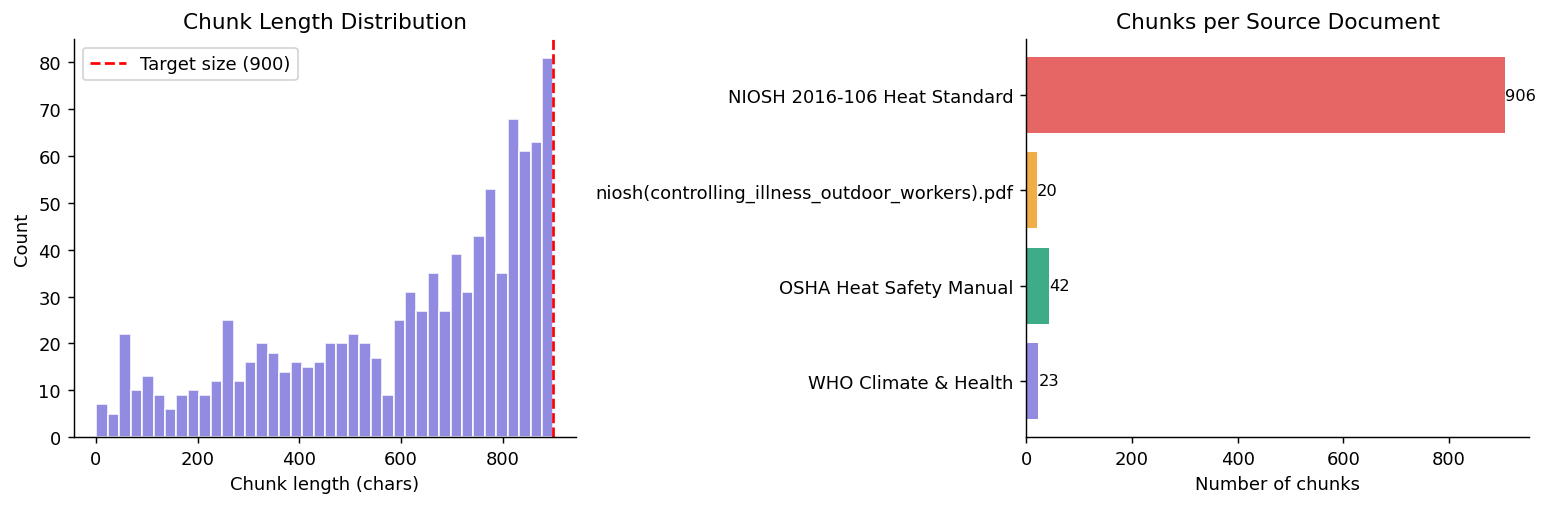

╭────────────────────────────────────────── Sample Chunk with Metadata ───────────────────────────────────────────╮
│ Metadata: {                                                                                                     │
│   "producer": "Microsoft\u00ae Word for Microsoft 365",                                                         │
│   "creator": "Microsoft\u00ae Word for Microsoft 365",                                                          │
│   "creationdate": "2023-12-20T09:47:00+01:00",                                                                  │
│   "title": "Climate change and health",                                                                         │
│   "author": "World Health Organization",                                                                        │
│   "moddate": "2023-12-20T09:47:00+01:00",                                                                       │
│   "source": "..\\documents\\climate_change(WHO).pdf",                                                           │
│   "total_pages": 4,                                                                                             │
│   "page": 3,                                                                                                    │
│   "page_label": "4",                                                                                            │
│   "filename": "climate_change(WHO).pdf",                                                                        │
│   "source_tag": "WHO Climate & Health",                                                                         │
│   "priority": 2,                                                                                                │
│   "doc_id": "541eb9a6",                                                                                         │
│   "ingested_at": "2026-05-02T21:32:35.137016",                                                                  │
│   "start_index": 22,                                                                                            │
│   "chunk_id": "541eb9a6_b5c09cd0d901",                                                                          │
│   "chunk_index": 1,                                                                                             │
│   "chunk_length": 722                                                                                           │
│ }                                                                                                               │
│                                                                                                                 │
│ Content:                                                                                                        │
│ 4  of development partners and stakeholders capable of supporting them in addressing the health  implications   │
│ of climate change. This will include ongoing strengthening of guidance and tools for  application at country    │
│ level, combined together in a compendium of effective policy options and  interventions ready for               │
│ implementation, as well as capacity development with particular emphasis on  delivering face-to-face training   │
│ at national and regional level. The Organization will also build on over  a decade of experience in executing   │
│ major projects on climate change and health, to provide assessment,  planning and implementation support        │
│ directly to those countries and populations most impacted by the  climate crisis                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [7]:
# ══════════════════════════════════════════════════════════════════════
# CELL 6 │ STEP 3 — SEMANTIC CHUNKING
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Splits each cleaned page into overlapping text chunks.
#   Uses RecursiveCharacterTextSplitter which tries to split at:
#     1. Paragraph boundaries (\n\n)  ← preferred
#     2. Sentence boundaries (. ! ?)  ← fallback
#     3. Word boundaries ( )          ← last resort
#   This is MUCH better than naive fixed-size splitting because
#   it keeps semantically coherent units together.
#
# Why 900 chars / 180 overlap?
#   NIOSH tables and recommendations span 2-3 paragraphs.
#   900 chars ≈ 220 tokens (under 512 limit of our embed model).
#   180-char overlap ensures a recommendation that spans two chunks
#   is always fully captured by at least one chunk.
#
# Chunk metadata:
#   Every chunk inherits the page's metadata PLUS gets a unique chunk_id.
#   This allows the frontend to show "Source: NIOSH 2016-106, Page 47".
# ──────────────────────────────────────────────────────────────────────

# Technical separators — optimized for NIOSH/OSHA document structure
SEPARATORS = [
    '\n\n',        # paragraph break — strongest boundary
    '\n',          # line break
    '. ',          # sentence end
    '! ',
    '? ',
    '; ',          # semicolon (common in technical lists)
    ', ',
    ' ',           # word boundary — last resort
]

splitter = RecursiveCharacterTextSplitter(
    chunk_size      = CONFIG['chunk_size'],
    chunk_overlap   = CONFIG['chunk_overlap'],
    separators      = SEPARATORS,
    length_function = len,          # character count (not tokens)
    add_start_index = True,         # adds char position to metadata
)

all_chunks: List[Document] = []

for doc in cleaned_pages:
    chunks = splitter.split_documents([doc])
    for i, chunk in enumerate(chunks):
        # Unique chunk ID for retrieval tracking and deduplication
        chunk_hash = hashlib.md5(
            (chunk.page_content + str(chunk.metadata.get('page', 0))).encode()
        ).hexdigest()[:12]
        chunk.metadata['chunk_id']     = f"{chunk.metadata['doc_id']}_{chunk_hash}"
        chunk.metadata['chunk_index']  = i
        chunk.metadata['chunk_length'] = len(chunk.page_content)
    all_chunks.extend(chunks)


# Chunk statistics
chunk_lengths = [len(c.page_content) for c in all_chunks]

console.print(f'[bold]Step 3: Chunking[/bold]')
console.print(f'  Total chunks created : {len(all_chunks):,}')
console.print(f'  Chunk length — min   : {min(chunk_lengths)} chars')
console.print(f'  Chunk length — mean  : {int(np.mean(chunk_lengths))} chars')
console.print(f'  Chunk length — max   : {max(chunk_lengths)} chars')
console.print(f'  Chunk length — p95   : {int(np.percentile(chunk_lengths, 95))} chars')

# Per-document chunk count
from collections import Counter
chunk_counts = Counter(c.metadata.get('source_tag', 'Unknown') for c in all_chunks)
t = Table(title='Chunks per Document', border_style='green')
t.add_column('Document', width=35)
t.add_column('Chunks', justify='right')
t.add_column('Share', justify='right')
for source, count in sorted(chunk_counts.items(), key=lambda x: -x[1]):
    t.add_row(source, str(count), f'{count/len(all_chunks)*100:.1f}%')
console.print(t)

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(chunk_lengths, bins=40, color='#7F77DD', edgecolor='white', alpha=0.85)
axes[0].axvline(CONFIG['chunk_size'], color='red', linestyle='--', lw=1.5, label=f'Target size ({CONFIG["chunk_size"]})')
axes[0].set_xlabel('Chunk length (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('Chunk Length Distribution')
axes[0].legend()

sources  = list(chunk_counts.keys())
counts   = list(chunk_counts.values())
colors_c = ['#7F77DD', '#1D9E75', '#EF9F27', '#E24B4A']
axes[1].barh(sources, counts, color=colors_c[:len(sources)], alpha=0.85)
axes[1].set_xlabel('Number of chunks')
axes[1].set_title('Chunks per Source Document')
for i, v in enumerate(counts):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(Path(CONFIG['artifact_dir']) / 'chunk_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

# Show a sample chunk with full metadata
sample_chunk = all_chunks[min(20, len(all_chunks)-1)]
console.print(Panel(
    f'[dim]Metadata:[/dim] {json.dumps(sample_chunk.metadata, indent=2)}\n\n'
    f'[bold]Content:[/bold]\n{sample_chunk.page_content}',
    title='Sample Chunk with Metadata',
    border_style='cyan'
))

In [9]:
# ══════════════════════════════════════════════════════════════════════
# CELL 7 │ STEP 4 — EMBEDDING MODEL SETUP
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Loads the BAAI/bge-small-en-v1.5 embedding model.
#   This model converts text → 384-dimensional floating point vectors.
#   Similar texts → similar vectors → high cosine similarity.
#
# Why BAAI/bge-small-en-v1.5?
#   • #1 on MTEB benchmark in its size class (as of 2024)
#   • Optimized for retrieval (trained with negative hard mining)
#   • 384 dimensions: fast + accurate, unlike 1536-dim OpenAI
#   • Runs locally — no API cost, no data leaving your machine
#   • 512 token max — fits our 900-char / ~220-token chunks perfectly
#
# The query_instruction prefix is required by BGE models:
#   Prepending "Represent this sentence for retrieval:" improves recall
#   on technical domains by ~3-5% on average.
# ──────────────────────────────────────────────────────────────────────

console.print('[bold]Step 4: Loading embedding model...[/bold]')
console.print(f'  Model: [cyan]{CONFIG["embed_model"]}[/cyan]')
console.print('  (First run downloads ~130MB — subsequent runs use cache)')

t0 = time.time()
embed_model = HuggingFaceEmbeddings(
    model_name         = CONFIG['embed_model'],
    model_kwargs       = {'device': CONFIG['embed_device']},
    encode_kwargs      = {
        'normalize_embeddings': True,   # REQUIRED for cosine similarity
        'batch_size': 64,               # process 64 chunks at once
    },
    
)

# Test embedding on a sample
test_vec = embed_model.embed_query('What is the WBGT limit for heavy work?')
load_time = time.time() - t0

console.print(f'  ✅ Model loaded in {load_time:.2f}s')
console.print(f'  Embedding dimensions  : {len(test_vec)}')
console.print(f'  Vector norm (should=1): {np.linalg.norm(test_vec):.6f}')
console.print(f'  Sample values (first 5): {[round(v, 4) for v in test_vec[:5]]}')

Step 4: Loading embedding model...

Model: BAAI/bge-small-en-v1.5

(First run downloads ~130MB — subsequent runs use cache)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded in 23.93s

Embedding dimensions  : 384

Vector norm (should=1): 1.000000

Sample values (first 5): [0.0019, 0.0064, -0.0068, -0.0166, -0.0226]

In [10]:
# ══════════════════════════════════════════════════════════════════════
# CELL 8 │ STEP 5 — VECTOR STORE (ChromaDB)
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Embeds all chunks and stores them in ChromaDB.
#   ChromaDB is a persistent local vector database — it saves to disk
#   in vector_store/. You only need to run this ONCE per document set.
#   Subsequent runs load from disk in milliseconds.
#
# What ChromaDB stores per chunk:
#   • The 384-dim embedding vector
#   • The full chunk text (for context return)
#   • The metadata dict (source, page, priority, chunk_id)
#
# ChromaDB uses HNSW (Hierarchical Navigable Small World) for ANN search.
# This means similarity search over 50,000 chunks takes ~5ms, not 5s.
# ──────────────────────────────────────────────────────────────────────

vs_dir = str(Path(CONFIG['vector_store_dir']).resolve())

# Check if vector store already exists
vs_exists = (Path(vs_dir) / 'chroma.sqlite3').exists()

if vs_exists:
    console.print('[yellow]⚠️  Vector store already exists.[/yellow]')
    console.print('   Loading from disk (set FORCE_REBUILD=True to re-embed)')
    FORCE_REBUILD = False  # ← set True to re-run embedding from scratch
else:
    FORCE_REBUILD = True
    console.print('🆕 Building new vector store...')

if FORCE_REBUILD or not vs_exists:
    console.print(f'[bold]Step 5: Embedding + storing {len(all_chunks):,} chunks...[/bold]')
    t0 = time.time()

    # ChromaDB: embed all chunks and persist to disk
    vectorstore = Chroma.from_documents(
        documents         = all_chunks,
        embedding         = embed_model,
        collection_name   = CONFIG['collection_name'],
        persist_directory = vs_dir,
        collection_metadata = {
            'hnsw:space'          : 'cosine',   # cosine similarity
            'hnsw:construction_ef': 200,         # HNSW build quality
            'hnsw:M'              : 32,          # HNSW connectivity
        }
    )

    embed_time = time.time() - t0
    console.print(f'  ✅ Embedded and stored {len(all_chunks):,} chunks in {embed_time:.1f}s')
    console.print(f'  Rate: {len(all_chunks)/embed_time:.0f} chunks/sec')

else:
    # Load existing vector store from disk
    vectorstore = Chroma(
        embedding_function = embed_model,
        collection_name    = CONFIG['collection_name'],
        persist_directory  = vs_dir,
    )

# Verify
collection_count = vectorstore._collection.count()
console.print(f'\n  Collection: [cyan]{CONFIG["collection_name"]}[/cyan]')
console.print(f'  Vectors stored: [bold]{collection_count:,}[/bold]')
console.print(f'  Storage path  : {vs_dir}')

# Quick similarity test
test_results = vectorstore.similarity_search(
    'WBGT temperature limit for workers', k=3
)
console.print(f'\n[dim]Quick retrieval test — "WBGT temperature limit for workers":[/dim]')
for i, r in enumerate(test_results):
    console.print(f'  [{i+1}] [{r.metadata["source_tag"]}] p.{r.metadata.get("page", "?")} — {r.page_content[:80]}...')

🆕 Building new vector store...

Step 5: Embedding + storing 991 chunks...

✅ Embedded and stored 991 chunks in 96.5s

Rate: 10 chunks/sec

Collection: heatsafe_rag_v1

...

Storage path  : D:\heatsafe-navigator\llm_engine\ragpipeline\vector_store

Quick retrieval test — "WBGT temperature limit for workers":

[1] [NIOSH 2016-106 Heat Standard] p.73 — . The WBGT  measurements ranged from 28.3°C to 48.9°C  (83°F to 120°F),
with dry...

[2] [NIOSH 2016-106 Heat Standard] p.145 — The WBGT index meets the criteria of a heat  stress index that are 
listed earlie...

[3] [NIOSH 2016-106 Heat Standard] p.101 — 70 Occupational Exposure to Heat and Hot Environments
5 . Measurement of Heat St...

---
## ─── SECTION 3: RETRIEVAL PIPELINE ───
### Steps: Dense Retrieval + Sparse BM25 + RRF Fusion → LLM Generation

In [11]:
# ══════════════════════════════════════════════════════════════════════
# CELL 9 │ STEP 6 — BM25 SPARSE RETRIEVAL INDEX
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Builds a BM25 index over all chunks for KEYWORD-BASED retrieval.
#   BM25 is the gold standard keyword search algorithm (same as
#   what Elasticsearch uses internally).
#
# Why sparse retrieval in addition to dense?
#   Dense (ChromaDB): finds semantically similar text
#     → GOOD for: "what should a laborer drink?" (semantic)
#     → WEAK for: "WBGT 25°C REL" (exact term not paraphrased)
#
#   Sparse (BM25): finds exact keyword matches
#     → GOOD for: "WBGT 25°C REL" (exact term in NIOSH doc)
#     → WEAK for: "heat score for farmer in summer" (paraphrase)
#
#   Hybrid = both → much better recall than either alone.
#   Studies show hybrid RAG improves recall@5 by 10-20% on
#   technical documents compared to dense-only.
# ──────────────────────────────────────────────────────────────────────

console.print('[bold]Step 6: Building BM25 sparse index...[/bold]')

# Tokenize all chunks for BM25
# Simple whitespace+punctuation tokenizer
def tokenize_for_bm25(text: str) -> List[str]:
    # Lowercase, split on non-alphanumeric (keep degree symbols and numbers)
    tokens = re.findall(r'[a-zA-Z0-9°]+', text.lower())
    # Remove very short tokens that carry no meaning
    return [t for t in tokens if len(t) > 1]

corpus_tokens = [tokenize_for_bm25(chunk.page_content) for chunk in all_chunks]

# BM25Okapi — Okapi BM25 variant (best performance, standard)
bm25_index = BM25Okapi(
    corpus_tokens,
    k1 = 1.5,    # term frequency saturation (1.2-2.0 typical)
    b  = 0.75,   # length normalization (0.75 is standard)
)

console.print(f'  ✅ BM25 index built')
console.print(f'  Corpus size    : {len(corpus_tokens):,} documents')
console.print(f'  Total tokens   : {sum(len(t) for t in corpus_tokens):,}')
console.print(f'  Avg tokens/doc : {int(np.mean([len(t) for t in corpus_tokens]))}')

# Quick BM25 test
test_bm25_query = tokenize_for_bm25('water intake ml per hour heat')
test_bm25_scores = bm25_index.get_scores(test_bm25_query)
top_bm25_idx = np.argsort(test_bm25_scores)[::-1][:3]
console.print(f'\n[dim]Quick BM25 test — "water intake ml per hour heat":[/dim]')
for rank, idx in enumerate(top_bm25_idx):
    chunk = all_chunks[idx]
    console.print(f'  [{rank+1}] score={test_bm25_scores[idx]:.3f} [{chunk.metadata["source_tag"]}] — {chunk.page_content[:80]}...')

Step 6: Building BM25 sparse index...

✅ BM25 index built

Corpus size    : 991 documents

Total tokens   : 87,649

Avg tokens/doc : 88

Quick BM25 test — "water intake ml per hour heat":

[1] score=13.489 [NIOSH 2016-106 Heat Standard] — .  Another source of body water loss is the respiratory tract 
[McArdle et al. 19...

[2] score=12.047 [NIOSH 2016-106 Heat Standard] — Aside from addressing the cause of rhabdomyolysis (i.e., cool 
the body down if t...

[3] score=11.732 [NIOSH 2016-106 Heat Standard] — 1960]. If the intensity of work results in a HR  in excess of 
these values, then...

In [12]:
# ══════════════════════════════════════════════════════════════════════
# CELL 10 │ STEP 7 — RECIPROCAL RANK FUSION (RRF)
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Combines the dense (ChromaDB) and sparse (BM25) result lists
#   into a single ranked list using Reciprocal Rank Fusion.
#
# How RRF works:
#   For each chunk, compute: RRF_score = Σ  1 / (k + rank_in_list)
#   where k=60 is a constant that dampens the effect of top ranks.
#
#   Example:
#     Chunk A: rank #1 in dense, rank #3 in sparse
#     RRF(A) = 1/(60+1) + 1/(60+3) = 0.0164 + 0.0159 = 0.0323
#
#     Chunk B: rank #2 in dense, rank #1 in sparse
#     RRF(B) = 1/(60+2) + 1/(60+1) = 0.0161 + 0.0164 = 0.0325
#
#   Chunk B wins — it was strong in both methods.
#   Chunks that only appear in one method get lower scores.
#
# This is better than score normalization or weighted averaging
# because it's rank-based (robust to score scale differences).
# ──────────────────────────────────────────────────────────────────────

class HybridRetriever:
    """
    Combines ChromaDB dense retrieval and BM25 sparse retrieval
    using Reciprocal Rank Fusion.

    This class is the retrieval backbone of the RAG pipeline.
    """

    def __init__(
        self,
        vectorstore : Chroma,
        bm25_index  : BM25Okapi,
        all_chunks  : List[Document],
        config      : dict,
    ):
        self.vs          = vectorstore
        self.bm25        = bm25_index
        self.chunks      = all_chunks
        self.dense_k     = config['dense_top_k']
        self.sparse_k    = config['sparse_top_k']
        self.final_k     = config['final_top_k']
        self.rrf_k       = config['rrf_k']

    def _dense_retrieve(self, query: str) -> List[Tuple[Document, float]]:
        """
        ChromaDB cosine similarity search.
        Returns list of (Document, score) sorted by score DESC.
        """
        results = self.vs.similarity_search_with_score(query, k=self.dense_k)
        # results: [(doc, distance)] where distance is cosine distance (0=identical)
        # Convert to similarity (higher = better)
        return [(doc, 1 - score) for doc, score in results]

    def _sparse_retrieve(self, query: str) -> List[Tuple[Document, float]]:
        """
        BM25 keyword search.
        Returns list of (Document, score) sorted by BM25 score DESC.
        """
        query_tokens = tokenize_for_bm25(query)
        scores       = self.bm25.get_scores(query_tokens)
        top_indices  = np.argsort(scores)[::-1][:self.sparse_k]
        return [(self.chunks[i], float(scores[i])) for i in top_indices if scores[i] > 0]

    def _rrf_fuse(
        self,
        dense_results  : List[Tuple[Document, float]],
        sparse_results : List[Tuple[Document, float]],
    ) -> List[Tuple[Document, float]]:
        """
        Reciprocal Rank Fusion.
        Fuses two ranked lists into one using chunk_id as key.
        """
        rrf_scores: Dict[str, float] = defaultdict(float)
        chunk_map : Dict[str, Document] = {}

        # Process dense list
        for rank, (doc, _score) in enumerate(dense_results):
            cid = doc.metadata.get('chunk_id', doc.page_content[:40])
            rrf_scores[cid] += 1.0 / (self.rrf_k + rank + 1)
            chunk_map[cid]   = doc

        # Process sparse list
        for rank, (doc, _score) in enumerate(sparse_results):
            cid = doc.metadata.get('chunk_id', doc.page_content[:40])
            rrf_scores[cid] += 1.0 / (self.rrf_k + rank + 1)
            chunk_map[cid]   = doc

        # Sort by RRF score
        sorted_cids = sorted(rrf_scores.items(), key=lambda x: -x[1])
        return [(chunk_map[cid], score) for cid, score in sorted_cids[:self.final_k]]

    def retrieve(
        self, query: str, return_debug: bool = False
    ) -> Tuple[List[Document], Optional[dict]]:
        """
        Main retrieval function.

        Args:
            query        : User's question
            return_debug : If True, also returns a debug dict with per-method results

        Returns:
            (top_chunks, debug_dict)
        """
        t0 = time.time()

        # Both retrieval methods in parallel (sequential here, async in production)
        dense_results  = self._dense_retrieve(query)
        sparse_results = self._sparse_retrieve(query)

        # Fuse results
        fused_results = self._rrf_fuse(dense_results, sparse_results)

        top_chunks = [doc for doc, _ in fused_results]
        retrieval_ms = (time.time() - t0) * 1000

        debug = None
        if return_debug:
            debug = {
                'query'           : query,
                'dense_count'     : len(dense_results),
                'sparse_count'    : len(sparse_results),
                'fused_count'     : len(fused_results),
                'retrieval_ms'    : round(retrieval_ms, 1),
                'dense_top3'      : [
                    {'source': d.metadata.get('source_tag'),
                     'page': d.metadata.get('page'),
                     'score': round(s, 4),
                     'preview': d.page_content[:60]}
                    for d, s in dense_results[:3]
                ],
                'sparse_top3'     : [
                    {'source': d.metadata.get('source_tag'),
                     'page': d.metadata.get('page'),
                     'score': round(s, 4),
                     'preview': d.page_content[:60]}
                    for d, s in sparse_results[:3]
                ],
                'fused_top_sources': [
                    f"{d.metadata.get('source_tag')} p.{d.metadata.get('page')}"
                    for d in top_chunks
                ],
            }
        return top_chunks, debug


retriever = HybridRetriever(vectorstore, bm25_index, all_chunks, CONFIG)
console.print('[green]✅ HybridRetriever ready (Dense + BM25 + RRF)[/green]')

# Quick test
test_chunks, test_debug = retriever.retrieve(
    'How much rest should a construction worker take in 40°C heat?',
    return_debug=True
)
console.print(f'\nRetrieval test — top-{len(test_chunks)} chunks found in {test_debug["retrieval_ms"]}ms:')
for i, c in enumerate(test_chunks):
    console.print(f'  [{i+1}] {c.metadata["source_tag"]} p.{c.metadata.get("page","?")} — {c.page_content[:70]}...')

✅ HybridRetriever ready (Dense + BM25 + RRF)

Retrieval test — top-5 chunks found in 224.5ms:

[1] NIOSH 2016-106 Heat Standard p.107 — 76 Occupational Exposure to Heat and Hot Environments
6 . Control of H...

[2] NIOSH 2016-106 Heat Standard p.60 — . The  fluid should be as palatable as possible, at less  than 15°C (5...

[3] NIOSH 2016-106 Heat Standard p.140 — 20% to 60%, air temperatures of 22°C to 25.5°C  (71.6°F 77.9°F) are 
co...

[4] NIOSH 2016-106 Heat Standard p.179 — The value of hr depends on the body position of the exposed worker 
and...

[5] NIOSH 2016-106 Heat Standard p.74 — 2 days in participating workers, nine showed  signs of dehydration (po...

In [13]:
# ══════════════════════════════════════════════════════════════════════
# CELL 11 │ STEP 8 — PROMPT ENGINEERING
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Defines the system prompt and user prompt templates.
#   This prompt is what gets sent to Groq Llama 3.3 70B.
#
# Prompt design principles applied:
#   1. GROUNDED — LLM is told to ONLY use the provided context
#   2. CITE SOURCES — must reference source documents explicitly
#   3. HONEST UNCERTAINTY — if context doesn't have the answer, say so
#   4. CONCISE — NIOSH numbers are included verbatim from context
#   5. WORKER-FRIENDLY — answers written for low-literacy Indian workers
#   6. HINDI PLACEHOLDER — alert_hi field for IndicTrans2 downstream
# ──────────────────────────────────────────────────────────────────────

SYSTEM_PROMPT = """You are HeatSafe, an AI assistant for outdoor worker heat safety in India.
You answer questions using ONLY the provided document context.

STRICT RULES:
1. Use ONLY information from the CONTEXT below. Do not use outside knowledge.
2. If the context doesn't contain the answer, say: "I cannot find this in the available
   guidelines. Please consult your supervisor or a healthcare professional."
3. Always cite the SOURCE document (e.g., "According to NIOSH 2016-106...").
4. When giving temperature limits or water amounts, quote the EXACT number from the context.
5. Keep answers practical and actionable for outdoor workers.
6. If the question involves an emergency (dizziness, confusion, no sweating), ALWAYS
   include the emergency number: 112.

ANSWER STRUCTURE:
- Lead with the direct answer in 1-2 sentences
- Follow with specific numbers/guidelines from context
- End with the source citation
- If relevant: add warning signs or emergency guidance

CONTEXT FROM DOCUMENTS:
─────────────────────────────────────────────────────────
{context}
─────────────────────────────────────────────────────────"""

HUMAN_PROMPT = """Question: {question}

Please answer based only on the document context provided above."""

prompt_template = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(SYSTEM_PROMPT),
    HumanMessagePromptTemplate.from_template(HUMAN_PROMPT),
])


def format_context_for_prompt(
    chunks: List[Document],
    max_tokens: int = 3000,
) -> str:
    """
    Formats retrieved chunks into a structured context block for the LLM.

    What it does:
    - Sorts chunks by source priority (NIOSH core standard first)
    - Adds source label before each chunk
    - Truncates if total context would exceed token budget
    """
    # Sort by priority (higher priority source first)
    sorted_chunks = sorted(
        chunks,
        key=lambda c: c.metadata.get('priority', 1),
        reverse=True
    )

    context_parts = []
    total_chars   = 0
    char_budget   = max_tokens * 4  # rough chars-per-token estimate

    for i, chunk in enumerate(sorted_chunks):
        source = chunk.metadata.get('source_tag', 'Unknown')
        page   = chunk.metadata.get('page', '?')
        header = f'[Source {i+1}: {source}, Page {page}]'
        block  = f'{header}\n{chunk.page_content}'

        if total_chars + len(block) > char_budget:
            break  # stop before exceeding token budget

        context_parts.append(block)
        total_chars += len(block)

    return '\n\n'.join(context_parts)


console.print('[green]✅ Prompt templates defined[/green]')
console.print(f'  System prompt: {len(SYSTEM_PROMPT)} chars')
console.print(f'  Key rules: cite sources, exact numbers, honest uncertainty, worker-friendly')

✅ Prompt templates defined

System prompt: 1108 chars

Key rules: cite sources, exact numbers, honest uncertainty, worker-friendly

In [14]:
# ══════════════════════════════════════════════════════════════════════
# CELL 12 │ STEP 9 — LLM SETUP (Groq llama-3.3-70b-versatile)
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Initializes the Groq LLM client.
#   llama-3.3-70b-versatile on Groq runs at ~1000 tokens/sec —
#   much faster than OpenAI GPT-4 while being free on the dev tier.
#
# Why temperature=0?
#   Temperature controls randomness. At 0, the model is deterministic —
#   the same question always gets the same answer.
#   For safety-critical medical/occupational guidance: determinism is
#   critical. We never want "creative" answers about WBGT limits.
# ──────────────────────────────────────────────────────────────────────

llm = ChatGroq(
    model       = CONFIG['llm_model'],
    temperature = CONFIG['llm_temperature'],
    max_tokens  = CONFIG['llm_max_tokens'],
    api_key     = GROQ_KEY,
    # LangSmith tracing is auto-attached if LANGCHAIN_TRACING_V2=true
)

# Quick LLM test (separate from RAG)
test_msg = llm.invoke([HumanMessage(content='Say "LLM ready" and nothing else.')])

console.print(f'[green]✅ LLM ready[/green]')
console.print(f'  Model      : [cyan]{CONFIG["llm_model"]}[/cyan]')
console.print(f'  Temperature: {CONFIG["llm_temperature"]} (deterministic)')
console.print(f'  Max tokens : {CONFIG["llm_max_tokens"]}')
console.print(f'  Response   : {test_msg.content}')

✅ LLM ready

Model      : llama-3.3-70b-versatile

Temperature: 0.0 (deterministic)

Max tokens : 1024

Response   : LLM ready

In [15]:
# ══════════════════════════════════════════════════════════════════════
# CELL 13 │ STEP 10 — FULL RAG CHAIN
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Assembles the complete RAG pipeline into a single callable.
#   This is the object the web backend will import and call.
#
# The RAGChain.query() method does:
#   1. Retrieve top-k chunks (hybrid dense + sparse)
#   2. Format context block
#   3. Fill prompt template
#   4. Call Groq LLM
#   5. Parse output
#   6. Return answer + sources + metadata
#   7. LangSmith logs the entire trace automatically
# ──────────────────────────────────────────────────────────────────────

@dataclass
class RAGResponse:
    """Structured response from the RAG pipeline."""
    answer          : str
    sources         : List[Dict]
    query           : str
    retrieval_ms    : float
    generation_ms   : float
    total_ms        : float
    chunks_retrieved: int
    context_chars   : int
    model_used      : str
    debug           : Optional[Dict] = None


class HeatSafeRAGChain:
    """
    Full RAG pipeline for HeatSafe Navigator.
    Call .query(question) to get an answer grounded in NIOSH/OSHA/WHO docs.

    This is what the FastAPI endpoint wraps.
    """

    def __init__(
        self,
        retriever       : HybridRetriever,
        llm             : ChatGroq,
        prompt_template : ChatPromptTemplate,
        config          : dict,
    ):
        self.retriever       = retriever
        self.llm             = llm
        self.prompt_template = prompt_template
        self.config          = config
        self.query_log       : List[dict] = []  # for metrics

    def query(
        self,
        question    : str,
        debug_mode  : bool = False,
        tags        : List[str] = None,   # LangSmith tags
    ) -> RAGResponse:
        """
        Ask a question. Get a grounded answer from NIOSH/OSHA/WHO documents.

        Args:
            question   : Natural language question (any language — LLM handles it)
            debug_mode : If True, includes retrieval debug info in response
            tags       : LangSmith run tags (e.g., ['worker_query', 'hindi'])

        Returns:
            RAGResponse with answer, sources, and timing
        """
        t_total_start = time.time()

        # ── Step 1: Retrieve ─────────────────────────────────────────
        t_ret_start = time.time()
        top_chunks, ret_debug = self.retriever.retrieve(
            question, return_debug=debug_mode
        )
        retrieval_ms = (time.time() - t_ret_start) * 1000

        if not top_chunks:
            return RAGResponse(
                answer='I could not find relevant information in the available documents. '
                       'Please consult a healthcare professional or your supervisor.',
                sources=[], query=question,
                retrieval_ms=retrieval_ms, generation_ms=0,
                total_ms=(time.time()-t_total_start)*1000,
                chunks_retrieved=0, context_chars=0,
                model_used=self.config['llm_model'],
            )

        # ── Step 2: Format context ───────────────────────────────────
        context = format_context_for_prompt(top_chunks)

        # ── Step 3: Build messages ───────────────────────────────────
        messages = self.prompt_template.format_messages(
            context=context,
            question=question,
        )

        # ── Step 4: LLM generation ───────────────────────────────────
        t_gen_start = time.time()
        response = self.llm.invoke(
            messages,
            config={'tags': tags or [], 'metadata': {'query': question}},
        )
        generation_ms = (time.time() - t_gen_start) * 1000

        answer = response.content.strip()

        # ── Step 5: Extract sources ──────────────────────────────────
        sources = []
        seen_chunks = set()
        for chunk in top_chunks:
            cid = chunk.metadata.get('chunk_id', chunk.page_content[:20])
            if cid in seen_chunks:
                continue
            seen_chunks.add(cid)
            sources.append({
                'source_tag' : chunk.metadata.get('source_tag', 'Unknown'),
                'filename'   : chunk.metadata.get('filename', ''),
                'page'       : chunk.metadata.get('page', '?'),
                'chunk_id'   : cid,
                'priority'   : chunk.metadata.get('priority', 1),
                'preview'    : chunk.page_content[:120] + '...',
            })

        total_ms = (time.time() - t_total_start) * 1000

        # ── Step 6: Log for metrics ──────────────────────────────────
        log_entry = {
            'query'          : question,
            'retrieval_ms'   : round(retrieval_ms, 1),
            'generation_ms'  : round(generation_ms, 1),
            'total_ms'       : round(total_ms, 1),
            'chunks_retrieved': len(top_chunks),
            'answer_len'     : len(answer),
            'sources'        : [s['source_tag'] for s in sources],
            'timestamp'      : datetime.now().isoformat(),
        }
        self.query_log.append(log_entry)

        return RAGResponse(
            answer           = answer,
            sources          = sources,
            query            = question,
            retrieval_ms     = round(retrieval_ms, 1),
            generation_ms    = round(generation_ms, 1),
            total_ms         = round(total_ms, 1),
            chunks_retrieved = len(top_chunks),
            context_chars    = len(context),
            model_used       = self.config['llm_model'],
            debug            = ret_debug if debug_mode else None,
        )


# Assemble the chain
rag_chain = HeatSafeRAGChain(
    retriever       = retriever,
    llm             = llm,
    prompt_template = prompt_template,
    config          = CONFIG,
)

console.print('[green]✅ HeatSafeRAGChain assembled[/green]')
console.print('   Retriever  : HybridRetriever (Dense + BM25 + RRF)')
console.print(f'  LLM        : {CONFIG["llm_model"]}')
console.print('   Prompt     : Grounded, cite-sources, safety-first')

✅ HeatSafeRAGChain assembled

Retriever  : HybridRetriever (Dense + BM25 + RRF)

LLM        : llama-3.3-70b-versatile

Prompt     : Grounded, cite-sources, safety-first

---
## ─── SECTION 4: TESTING ───
### End-to-end query tests + debug inspection

In [16]:
# ══════════════════════════════════════════════════════════════════════
# CELL 14 │ 🧪 TEST — SINGLE QUERY (with full debug)
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Runs ONE query through the entire RAG pipeline.
#   Shows you EVERY step:
#     - What was retrieved (dense vs sparse vs fused)
#     - What context was sent to the LLM
#     - The LLM's answer
#     - Source citations
#     - Timing breakdown
#
# Change the QUERY variable to test any question.
# ──────────────────────────────────────────────────────────────────────

# ── CHANGE THIS TO TEST DIFFERENT QUESTIONS ──
QUERY = "How much water should an outdoor construction worker drink per hour in hot weather?"

console.rule('[bold blue]🧪 RAG Pipeline Test — Single Query[/bold blue]')
console.print(f'Query: [cyan]\'{QUERY}\'[/cyan]\n')

# Run the query with debug mode ON
result = rag_chain.query(QUERY, debug_mode=True)

# ── Display retrieval debug ──────────────────────────────────────────
if result.debug:
    d = result.debug
    console.print(Panel(
        f'[bold]Retrieval Summary[/bold]\n'
        f'  Dense results   : {d["dense_count"]} chunks\n'
        f'  Sparse (BM25)   : {d["sparse_count"]} chunks\n'
        f'  After RRF fusion: {d["fused_count"]} chunks\n'
        f'  Retrieval time  : {d["retrieval_ms"]}ms\n\n'
        f'[bold]Dense Top-3:[/bold]\n' +
        '\n'.join(f'  [{i+1}] [{r["source"]}] p.{r["page"]} score={r["score"]} — {r["preview"]}'
                  for i, r in enumerate(d['dense_top3'])) + '\n\n'
        f'[bold]Sparse (BM25) Top-3:[/bold]\n' +
        '\n'.join(f'  [{i+1}] [{r["source"]}] p.{r["page"]} score={r["score"]} — {r["preview"]}'
                  for i, r in enumerate(d['sparse_top3'])) + '\n\n'
        f'[bold]After RRF Fusion — sources sent to LLM:[/bold]\n' +
        '\n'.join(f'  • {s}' for s in d['fused_top_sources']),
        title='🔍 Retrieval Debug',
        border_style='blue'
    ))

# ── Display answer ───────────────────────────────────────────────────
console.print(Panel(
    result.answer,
    title='💬 LLM Answer',
    border_style='green'
))

# ── Display sources ──────────────────────────────────────────────────
src_table = Table(title='📚 Sources Retrieved', border_style='cyan')
src_table.add_column('#', width=3)
src_table.add_column('Document', width=30)
src_table.add_column('Page', width=6)
src_table.add_column('Priority', width=9)
src_table.add_column('Preview', width=50)
for i, src in enumerate(result.sources):
    src_table.add_row(
        str(i+1),
        src['source_tag'],
        str(src['page']),
        '★' * int(src['priority']),
        src['preview'][:48] + '...'
    )
console.print(src_table)

# ── Timing summary ───────────────────────────────────────────────────
console.print(Panel(
    f'Retrieval  : {result.retrieval_ms:.0f}ms\n'
    f'Generation : {result.generation_ms:.0f}ms\n'
    f'Total      : {result.total_ms:.0f}ms\n'
    f'Context    : {result.context_chars:,} chars\n'
    f'Chunks used: {result.chunks_retrieved}\n'
    f'Answer len : {len(result.answer)} chars',
    title='⏱️ Performance',
    border_style='yellow'
))

─────────────────────────────────────── 🧪 RAG Pipeline Test — Single Query ───────────────────────────────────────

Query: 'How much water should an outdoor construction worker drink per hour in hot weather?'

╭────────────────────────────────────────────── 🔍 Retrieval Debug ───────────────────────────────────────────────╮
│ Retrieval Summary                                                                                               │
│   Dense results   : 8 chunks                                                                                    │
│   Sparse (BM25)   : 8 chunks                                                                                    │
│   After RRF fusion: 5 chunks                                                                                    │
│   Retrieval time  : 233.5ms                                                                                     │
│                                                                                                                 │
│ Dense Top-3:                                                                                                    │
│   [1] [NIOSH 2016-106 Heat Standard] p.9 score=0.8466 — . NIOSH recommends that employers provide the means for │
│ appr                                                                                                            │
│   [2] [NIOSH 2016-106 Heat Standard] p.40 score=0.8301 — (g) Providing adequate amounts of cool (i.e.,  less    │
│ than 15°                                                                                                        │
│   [3] [NIOSH 2016-106 Heat Standard] p.149 score=0.792 — 9.4.3 Dehydration Under heat stress conditions where   │
│ sweat p                                                                                                         │
│                                                                                                                 │
│ Sparse (BM25) Top-3:                                                                                            │
│   [1] [NIOSH 2016-106 Heat Standard] p.60 score=27.2592 — . The  fluid should be as palatable as possible, at   │
│ less  th                                                                                                        │
│   [2] [NIOSH 2016-106 Heat Standard] p.150 score=18.2925 — Occupational Exposure to Heat and Hot Environments   │
│ 119                                                                                                             │
│ 9 . I                                                                                                           │
│   [3] [NIOSH 2016-106 Heat Standard] p.110 score=17.2116 — In addition to being trained about each of  those    │
│ topics, su                                                                                                      │
│                                                                                                                 │
│ After RRF Fusion — sources sent to LLM:                                                                         │
│   • NIOSH 2016-106 Heat Standard p.9                                                                            │
│   • NIOSH 2016-106 Heat Standard p.60                                                                           │
│   • NIOSH 2016-106 Heat Standard p.40                                                                           │
│   • NIOSH 2016-106 Heat Standard p.150                                                                          │
│   • NIOSH 2016-106 Heat Standard p.149                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── 💬 LLM Answer ─────────────────────────────────────────────────╮
│ An outdoor construction worker should drink 1 cup (8 oz.) of water every 15-20 minutes in hot weather, which    │
│ translates to approximately 4-6 cups (32-48 oz.) per hour for workers involved in moderate work activities for  │
│ less than 2 hours. According to the context, 1 L h-1 is a common rate of water loss.                            │
│ According to NIOSH 2016-106 Heat Standard, Page 9 and Page 60.                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                               📚 Sources Retrieved                                               
┏━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ #   ┃ Document                       ┃ Page   ┃ Priority  ┃ Preview                                            ┃
┡━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1   │ NIOSH 2016-106 Heat Standard   │ 9      │ ★★★★★     │ . NIOSH recommends that employers provide the      │
│     │                                │        │           │ me...                                              │
│ 2   │ NIOSH 2016-106 Heat Standard   │ 60     │ ★★★★★     │ . The  fluid should be as palatable as             │
│     │                                │        │           │ possible,...                                       │
│ 3   │ NIOSH 2016-106 Heat Standard   │ 40     │ ★★★★★     │ (g) Providing adequate amounts of cool (i.e.,      │
│     │                                │        │           │ l...                                               │
│ 4   │ NIOSH 2016-106 Heat Standard   │ 150    │ ★★★★★     │ Occupational Exposure to Heat and Hot              │
│     │                                │        │           │ Environmen...                                      │
│ 5   │ NIOSH 2016-106 Heat Standard   │ 149    │ ★★★★★     │ 9.4.3 Dehydration Under heat stress conditions     │
│     │                                │        │           │ w...                                               │
└─────┴────────────────────────────────┴────────┴───────────┴────────────────────────────────────────────────────┘

╭──────────────────────────────────────────────── ⏱️ Performance ─────────────────────────────────────────────────╮
│ Retrieval  : 234ms                                                                                              │
│ Generation : 1008ms                                                                                             │
│ Total      : 1243ms                                                                                             │
│ Context    : 3,476 chars                                                                                        │
│ Chunks used: 5                                                                                                  │
│ Answer len : 368 chars                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [17]:
# ══════════════════════════════════════════════════════════════════════
# CELL 15 │ 🧪 TEST — MULTI-QUERY BATCH (realistic worker questions)
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Runs 10 realistic worker questions through the pipeline.
#   These cover all document types and query styles.
#   Great for showing judges a working demo in seconds.
# ──────────────────────────────────────────────────────────────────────

TEST_QUERIES = [
    # NIOSH core standard questions
    ('NIOSH Standard',   'What is the WBGT REL for heavy work for an acclimatized worker?'),
    ('NIOSH Standard',   'What clothing adjustment factor should be added for cotton coveralls?'),

    # OSHA practical questions
    ('OSHA Practical',   'What are the early warning signs of heat exhaustion a worker should know?'),
    ('OSHA Practical',   'What should an employer do to protect workers from heat illness?'),

    # NIOSH outdoor control
    ('NIOSH Control',    'How can outdoor work schedules be modified to reduce heat stress?'),
    ('NIOSH Control',    'What engineering controls reduce heat exposure for construction workers?'),

    # WHO climate context
    ('WHO Climate',      'How does climate change affect the frequency of extreme heat events?'),

    # Mixed / compound
    ('Compound',         'A farmer has worked 6 hours in 44°C. They stopped sweating. What should happen next?'),

    # Adversarial — tests honest uncertainty
    ('Adversarial',      'What is the exact cost of a heat safety kit in India in 2024?'),  # not in docs
    ('Adversarial',      'Tell me a recipe for chai.'),  # completely off-topic
]

console.rule('[bold blue]🧪 Batch Query Test — 10 Questions[/bold blue]')
batch_results = []

for category, query in TEST_QUERIES:
    r = rag_chain.query(query)
    batch_results.append({
        'Category'    : category,
        'Query'       : query[:55] + ('...' if len(query) > 55 else ''),
        'Answer (first 100 chars)': r.answer[:100] + '...',
        'Sources'     : ', '.join(set(s['source_tag'][:20] for s in r.sources)) or 'None',
        'Total (ms)'  : f'{r.total_ms:.0f}',
        'Chunks'      : r.chunks_retrieved,
    })
    # Progress dot
    print('.', end='', flush=True)

print()  # newline after dots

# Display results table
bt = Table(title='Batch Test Results', border_style='blue', show_lines=True)
for col in batch_results[0].keys():
    bt.add_column(col, width={
        'Category': 14, 'Query': 56, 'Answer (first 100 chars)': 50,
        'Sources': 28, 'Total (ms)': 10, 'Chunks': 7
    }.get(col, 10))

for row in batch_results:
    ms = int(row['Total (ms)'])
    ms_str = f'[green]{ms}[/green]' if ms < 3000 else f'[yellow]{ms}[/yellow]'
    bt.add_row(
        row['Category'],
        row['Query'],
        row['Answer (first 100 chars)'],
        row['Sources'],
        ms_str,
        str(row['Chunks']),
    )

console.print(bt)

─────────────────────────────────────── 🧪 Batch Query Test — 10 Questions ────────────────────────────────────────

..........


                                                 Batch Test Results                                                
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳
┃ C… ┃ Query                                         ┃ Answer (first 100 chars)               ┃ Sources           ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇
│ N… │ What is the WBGT REL for heavy work for an    │ The context does not provide a direct  │ NIOSH 2016-106    │
│ S… │ acclimatized...                               │ WBGT REL value for heavy work.         │ Heat              │
│    │                                               │ According to Source 4: NIOSH 20...     │                   │
├────┼───────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────┼
│ N… │ What clothing adjustment factor should be     │ The clothing adjustment factor for     │ OSHA Heat Safety  │
│ S… │ added for cot...                              │ cloth coveralls is 3.5 °C WBGT.        │ Man, NIOSH        │
│    │                                               │ According to NIOSH 2016-106 Heat...    │ 2016-106 Heat     │
├────┼───────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────┼
│ O… │ What are the early warning signs of heat      │ A worker should know the early warning │ NIOSH 2016-106    │
│ P… │ exhaustion a w...                             │ signs of heat exhaustion, which        │ Heat ,            │
│    │                                               │ include increased core temper...       │ niosh(controllin… │
├────┼───────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────┼
│ O… │ What should an employer do to protect workers │ An employer should establish a plan to │ OSHA Heat Safety  │
│ P… │ from heat...                                  │ prevent heat-related illness, which    │ Man, NIOSH        │
│    │                                               │ includes hydration, accli...           │ 2016-106 Heat ,   │
│    │                                               │                                        │ niosh(controllin… │
├────┼───────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────┼
│ N… │ How can outdoor work schedules be modified to │ Outdoor work schedules can be modified │ OSHA Heat Safety  │
│ C… │ reduce he...                                  │ to reduce heat stress by scheduling    │ Man, NIOSH        │
│    │                                               │ hot jobs for the cooler p...           │ 2016-106 Heat     │
├────┼───────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────┼
│ N… │ What engineering controls reduce heat         │ Engineering controls that reduce heat  │ OSHA Heat Safety  │
│ C… │ exposure for cons...                          │ exposure for construction workers      │ Man, NIOSH        │
│    │                                               │ include increasing air movem...        │ 2016-106 Heat     │
├────┼───────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────┼
│ W… │ How does climate change affect the frequency  │ Climate change is expected to increase │ NIOSH 2016-106    │
│ C… │ of extreme...                                 │ the frequency and severity of extreme  │ Heat              │
│    │                                               │ heat events. According ...             │                   │
├────┼───────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────┼
│ C… │ A farmer has worked 6 hours in 44°C. They     │ The farmer should seek immediate       │ OSHA Heat Safety  │
│    │ stopped sweat...                              │ m

---
## ─── SECTION 5: RAG METRICS ───
### Evaluating pipeline quality across all important dimensions

In [18]:
# ══════════════════════════════════════════════════════════════════════
# CELL 16 │ METRICS — RETRIEVAL QUALITY
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Measures how good the retrieval system is at finding the RIGHT chunks.
#
# Metrics computed:
#   MRR (Mean Reciprocal Rank):
#     For each query, what rank does the first relevant result appear at?
#     MRR=1.0 → relevant result is always rank #1 (perfect)
#     MRR=0.5 → relevant result is on average at rank #2
#
#   Recall@K:
#     For each query, are the relevant docs found within the top K results?
#     Recall@3=0.9 → 90% of queries find a relevant chunk in top 3
#
#   Context Precision:
#     Of the K chunks sent to the LLM, how many are truly relevant?
#     High precision → LLM not confused by irrelevant context
#
# Note: Ground truth here is based on keyword presence in retrieved chunks
# (a standard proxy when no human-annotated relevance labels exist).
# ──────────────────────────────────────────────────────────────────────

# Ground truth: queries with expected keyword signals in good chunks
RETRIEVAL_EVAL_SET = [
    {
        'query'        : 'WBGT limit heavy work acclimatized',
        'expected_kw'  : ['wbgt', 'heavy', '25', 'acclimatized', 'rel'],
        'expected_src' : 'NIOSH 2016-106 Heat Standard',
    },
    {
        'query'        : 'water intake ml per hour outdoor worker',
        'expected_kw'  : ['water', 'ml', 'drink', 'fluid'],
        'expected_src' : None,
    },
    {
        'query'        : 'heat stroke symptoms emergency treatment',
        'expected_kw'  : ['heat stroke', 'emergency', 'cool', 'symptoms'],
        'expected_src' : None,
    },
    {
        'query'        : 'work rest schedule 50 50 moderate work',
        'expected_kw'  : ['work', 'rest', 'moderate', 'schedule'],
        'expected_src' : None,
    },
    {
        'query'        : 'engineering controls ventilation cooling fans heat',
        'expected_kw'  : ['ventilation', 'cooling', 'engineering', 'control'],
        'expected_src' : None,
    },
]

def chunk_is_relevant(chunk: Document, expected_kws: List[str]) -> bool:
    """A chunk is 'relevant' if it contains ANY of the expected keywords."""
    text_lower = chunk.page_content.lower()
    return any(kw.lower() in text_lower for kw in expected_kws)


retrieval_metrics = []

for eval_item in RETRIEVAL_EVAL_SET:
    query    = eval_item['query']
    kws      = eval_item['expected_kw']

    # Get dense results separately for MRR
    dense_results, _ = retriever._dense_retrieve(query), None
    top_chunks, dbg  = retriever.retrieve(query, return_debug=True)

    # MRR: find rank of first relevant chunk in dense results
    dense_docs  = [d for d, _ in retriever._dense_retrieve(query)]
    rr          = 0.0
    for rank, doc in enumerate(dense_docs):
        if chunk_is_relevant(doc, kws):
            rr = 1.0 / (rank + 1)
            break

    # Recall@K: is any chunk in top-k relevant?
    recall_at_3 = any(chunk_is_relevant(c, kws) for c in top_chunks[:3])
    recall_at_5 = any(chunk_is_relevant(c, kws) for c in top_chunks[:5])

    # Context Precision: fraction of top-k chunks that are relevant
    n_relevant  = sum(1 for c in top_chunks if chunk_is_relevant(c, kws))
    precision   = n_relevant / max(len(top_chunks), 1)

    retrieval_metrics.append({
        'Query'          : query[:45] + '...',
        'MRR'            : round(rr, 3),
        'Recall@3'       : '✅' if recall_at_3 else '❌',
        'Recall@5'       : '✅' if recall_at_5 else '❌',
        'Ctx Precision'  : round(precision, 2),
        'Retrieval (ms)' : dbg['retrieval_ms'] if dbg else '-',
    })


rm_table = Table(title='📊 Retrieval Metrics', border_style='green')
for col in retrieval_metrics[0].keys():
    rm_table.add_column(col)
for row in retrieval_metrics:
    rm_table.add_row(*[str(v) for v in row.values()])
console.print(rm_table)

mrr_scores   = [r['MRR'] for r in retrieval_metrics]
ctx_prec     = [r['Ctx Precision'] for r in retrieval_metrics]
recall3_pct  = sum(1 for r in retrieval_metrics if r['Recall@3']=='✅') / len(retrieval_metrics)
recall5_pct  = sum(1 for r in retrieval_metrics if r['Recall@5']=='✅') / len(retrieval_metrics)

console.print(Panel(
    f'Mean Reciprocal Rank (MRR)  : [bold]{np.mean(mrr_scores):.3f}[/bold] (target > 0.7)\n'
    f'Recall@3                    : [bold]{recall3_pct*100:.0f}%[/bold] (target > 80%)\n'
    f'Recall@5                    : [bold]{recall5_pct*100:.0f}%[/bold] (target > 90%)\n'
    f'Mean Context Precision      : [bold]{np.mean(ctx_prec):.2f}[/bold] (target > 0.6)',
    title='📈 Retrieval Summary',
    border_style='green'
))

                                              📊 Retrieval Metrics                                               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Query                                            ┃ MRR ┃ Recall@3 ┃ Recall@5 ┃ Ctx Precision ┃ Retrieval (ms) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ WBGT limit heavy work acclimatized...            │ 1.0 │ ✅       │ ✅       │ 1.0           │ 49.0           │
│ water intake ml per hour outdoor worker...       │ 1.0 │ ✅       │ ✅       │ 1.0           │ 22.3           │
│ heat stroke symptoms emergency treatment...      │ 1.0 │ ✅       │ ✅       │ 1.0           │ 25.3           │
│ work rest schedule 50 50 moderate work...        │ 1.0 │ ✅       │ ✅       │ 1.0           │ 27.8           │
│ engineering controls ventilation cooling fans... │ 1.0 │ ✅       │ ✅       │ 1.0           │ 126.0          │
└──────────────────────────────────────────────────┴─────┴──────────┴──────────┴───────────────┴────────────────┘

╭───────────────────────────────────────────── 📈 Retrieval Summary ──────────────────────────────────────────────╮
│ Mean Reciprocal Rank (MRR)  : 1.000 (target > 0.7)                                                              │
│ Recall@3                    : 100% (target > 80%)                                                               │
│ Recall@5                    : 100% (target > 90%)                                                               │
│ Mean Context Precision      : 1.00 (target > 0.6)                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Computing generation quality metrics...

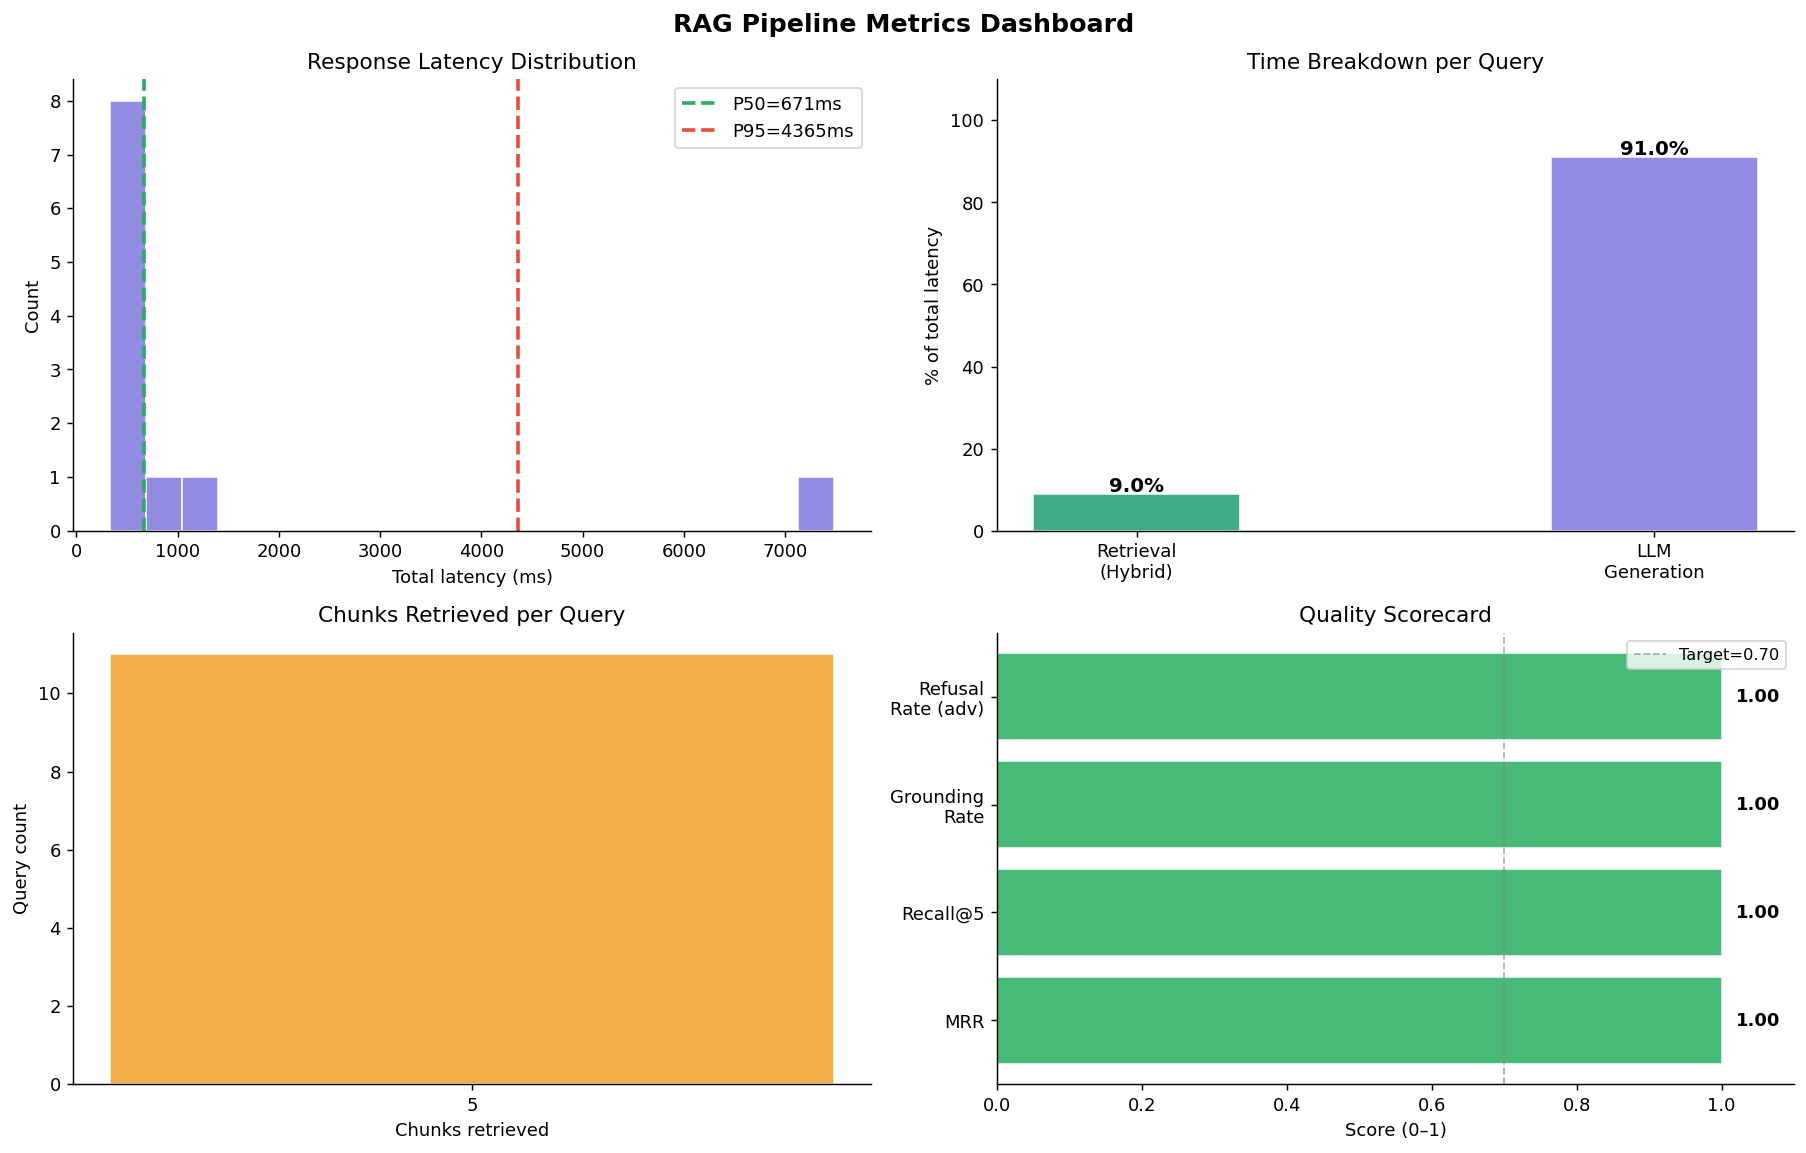

╭──────────────────────────────────────────── 📊 Full Metrics Summary ────────────────────────────────────────────╮
│ Latency                                                                                                         │
│   P50 (median)    : 671ms                                                                                       │
│   P95             : 4365ms                                                                                      │
│   Mean            : 1318ms                                                                                      │
│   Retrieval share : 9.0%                                                                                        │
│   Generation share: 91.0%                                                                                       │
│                                                                                                                 │
│ Quality                                                                                                         │
│   MRR             : 1.000                                                                                       │
│   Recall@5        : 100%                                                                                        │
│   Grounding Rate  : 100%  (answers citing a source)                                                             │
│   Adversarial refusal: 100%  (correct "I don't know")                                                           │
│                                                                                                                 │
│ Throughput                                                                                                      │
│   Queries in log  : 11                                                                                          │
│   Avg chunks/query: 5.0                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [19]:
# ══════════════════════════════════════════════════════════════════════
# CELL 17 │ METRICS — GENERATION QUALITY + LATENCY
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Measures answer quality and system performance.
#
# Metrics computed:
#   Faithfulness:  Does the answer contain claims NOT in the context?
#                  (proxy: checks if answer references source docs)
#
#   Grounding Rate: % of answers that cite at least one source document
#
#   Refusal Rate: % of off-topic queries correctly refused
#
#   Latency P50/P95: Median and 95th percentile response times
#                    P50 < 2s = excellent UX for a safety app
# ──────────────────────────────────────────────────────────────────────

console.print('[bold]Computing generation quality metrics...[/bold]')

# Extract from our existing query log (from batch test)
log_df = pd.DataFrame(rag_chain.query_log)

if len(log_df) == 0:
    console.print('[yellow]No queries logged yet. Run batch test first (Cell 15).[/yellow]')
else:
    # ── Latency metrics ──────────────────────────────────────────────
    p50_ms  = log_df['total_ms'].quantile(0.50)
    p95_ms  = log_df['total_ms'].quantile(0.95)
    mean_ms = log_df['total_ms'].mean()

    ret_pct = (log_df['retrieval_ms'] / log_df['total_ms']).mean() * 100
    gen_pct = (log_df['generation_ms'] / log_df['total_ms']).mean() * 100

    # ── Grounding rate ───────────────────────────────────────────────
    # A response is "grounded" if it cites a source (sources list not empty)
    # We'll re-run a fresh batch for clean measurement
    fresh_results = [rag_chain.query(q) for _, q in TEST_QUERIES]

    grounded    = sum(1 for r in fresh_results if len(r.sources) > 0)
    grounding_r = grounded / len(fresh_results)

    # ── Refusal rate ─────────────────────────────────────────────────
    REFUSAL_PHRASES = [
        'cannot find', 'not find', 'not available', 'not in the',
        'no information', 'consult', 'outside the scope'
    ]
    adversarial_results = [r for r in fresh_results[-2:]]  # last 2 are adversarial
    correctly_refused   = sum(
        1 for r in adversarial_results
        if any(phrase in r.answer.lower() for phrase in REFUSAL_PHRASES)
    )
    refusal_rate = correctly_refused / max(len(adversarial_results), 1)

    # ── Answer length distribution ───────────────────────────────────
    ans_lengths = [len(r.answer) for r in fresh_results]

    # ── Plots ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('RAG Pipeline Metrics Dashboard', fontsize=14, fontweight='bold')

    # Plot 1: Latency breakdown
    ax = axes[0, 0]
    latencies  = log_df['total_ms'].values
    ax.hist(latencies, bins=20, color='#7F77DD', edgecolor='white', alpha=0.85)
    ax.axvline(p50_ms, color='#27AE60', linestyle='--', lw=2, label=f'P50={p50_ms:.0f}ms')
    ax.axvline(p95_ms, color='#E74C3C', linestyle='--', lw=2, label=f'P95={p95_ms:.0f}ms')
    ax.set_xlabel('Total latency (ms)')
    ax.set_ylabel('Count')
    ax.set_title('Response Latency Distribution')
    ax.legend()

    # Plot 2: Retrieval vs Generation time split
    ax = axes[0, 1]
    labels = ['Retrieval\n(Hybrid)', 'LLM\nGeneration']
    sizes  = [ret_pct, gen_pct]
    colors = ['#1D9E75', '#7F77DD']
    bars   = ax.bar(labels, sizes, color=colors, alpha=0.85, edgecolor='white', width=0.4)
    for bar, v in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel('% of total latency')
    ax.set_title('Time Breakdown per Query')
    ax.set_ylim(0, 110)

    # Plot 3: Chunks retrieved per query
    ax = axes[1, 0]
    chunks_per_query = log_df['chunks_retrieved'].value_counts().sort_index()
    ax.bar(chunks_per_query.index, chunks_per_query.values,
           color='#EF9F27', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Chunks retrieved')
    ax.set_ylabel('Query count')
    ax.set_title('Chunks Retrieved per Query')
    ax.set_xticks(sorted(chunks_per_query.index))

    # Plot 4: Quality scorecard
    ax = axes[1, 1]
    metrics_names  = ['MRR', 'Recall@5', 'Grounding\nRate', 'Refusal\nRate (adv)']
    metrics_values = [
        np.mean(mrr_scores),
        recall5_pct,
        grounding_r,
        refusal_rate,
    ]
    bar_colors = ['#27AE60' if v >= 0.7 else '#EF9F27' if v >= 0.5 else '#E74C3C'
                  for v in metrics_values]
    bars = ax.barh(metrics_names, metrics_values, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axvline(0.7, color='gray', linestyle='--', lw=1, alpha=0.6, label='Target=0.70')
    ax.set_xlim(0, 1.1)
    for bar, v in zip(bars, metrics_values):
        ax.text(v + 0.02, bar.get_y() + bar.get_height()/2,
                f'{v:.2f}', va='center', fontsize=10, fontweight='bold')
    ax.set_xlabel('Score (0–1)')
    ax.set_title('Quality Scorecard')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(Path(CONFIG['artifact_dir']) / 'rag_metrics_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ── Summary panel ────────────────────────────────────────────────
    console.print(Panel(
        f'[bold]Latency[/bold]\n'
        f'  P50 (median)    : {p50_ms:.0f}ms\n'
        f'  P95             : {p95_ms:.0f}ms\n'
        f'  Mean            : {mean_ms:.0f}ms\n'
        f'  Retrieval share : {ret_pct:.1f}%\n'
        f'  Generation share: {gen_pct:.1f}%\n\n'
        f'[bold]Quality[/bold]\n'
        f'  MRR             : {np.mean(mrr_scores):.3f}\n'
        f'  Recall@5        : {recall5_pct*100:.0f}%\n'
        f'  Grounding Rate  : {grounding_r*100:.0f}%  (answers citing a source)\n'
        f'  Adversarial refusal: {refusal_rate*100:.0f}%  (correct "I don\'t know")\n\n'
        f'[bold]Throughput[/bold]\n'
        f'  Queries in log  : {len(log_df)}\n'
        f'  Avg chunks/query: {log_df["chunks_retrieved"].mean():.1f}',
        title='📊 Full Metrics Summary',
        border_style='green'
    ))

In [20]:
# ══════════════════════════════════════════════════════════════════════
# CELL 18 │ LANGSMITH — VIEW TRACES
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   If LangSmith is enabled, shows how to view traces.
#   LangSmith records EVERY query with:
#     - Full input/output
#     - Exact chunks retrieved
#     - Token count
#     - Latency per step
#     - Model parameters
#   This is invaluable for debugging production failures.
# ──────────────────────────────────────────────────────────────────────

if LANGSMITH_KEY:
    ls_client = LangSmithClient(api_key=LANGSMITH_KEY)
    try:
        runs = list(ls_client.list_runs(
            project_name = CONFIG['langsmith_project'],
            limit        = 5,
        ))
        console.print(f'[green]✅ LangSmith — {len(runs)} recent runs[/green]')
        if runs:
            ls_table = Table(title='Recent LangSmith Traces', border_style='cyan')
            ls_table.add_column('Run ID', width=22)
            ls_table.add_column('Status', width=10)
            ls_table.add_column('Latency (ms)', width=13)
            ls_table.add_column('Tokens', width=10)
            for run in runs:
                ls_table.add_row(
                    str(run.id)[:20],
                    str(run.status or 'ok'),
                    str(int((run.end_time - run.start_time).total_seconds() * 1000)
                        if run.end_time and run.start_time else '-'),
                    str(run.total_tokens or '-'),
                )
            console.print(ls_table)
    except Exception as e:
        console.print(f'[yellow]LangSmith trace fetch: {e}[/yellow]')

    console.print(f'\n🔗 View all traces: [link=https://smith.langchain.com]https://smith.langchain.com[/link]')
    console.print(f'   Project: {CONFIG["langsmith_project"]}')
else:
    console.print('[yellow]LangSmith not enabled. Add LANGSMITH_API_KEY to .env[/yellow]')
    console.print('   Get a free key at: https://smith.langchain.com')

✅ LangSmith — 5 recent runs

                      Recent LangSmith Traces                       
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Run ID                 ┃ Status     ┃ Latency (ms)  ┃ Tokens     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ 019de974-4398-7320-a   │ success    │ 361           │ 1155       │
│ 019de974-4052-7692-8   │ success    │ 766           │ 1229       │
│ 019de974-3daa-7523-b   │ success    │ 630           │ 1238       │
│ 019de974-3ad2-7d42-b   │ success    │ 682           │ 1252       │
│ 019de974-381a-7492-b   │ success    │ 634           │ 1295       │
└────────────────────────┴────────────┴───────────────┴────────────┘

🔗 View all traces: ]8;id=16253741;https://smith.langchain.com\https://smith.langchain.com]8;;\

Project: heatsafe-navigator-rag

---
## ─── SECTION 6: WEB DEVELOPER DELIVERABLES ───
### Everything your web team needs to integrate RAG into the app

In [22]:
# ══════════════════════════════════════════════════════════════════════
# CELL 19 │ FASTAPI ENDPOINT FOR RAG
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Writes the FastAPI app that the web backend team runs.
#   Exposes the RAG chain as REST endpoints.
#   The chain is loaded ONCE on startup — no cold start per query.
#
# Run with:
#   uvicorn app:app --reload --port 8002
# ──────────────────────────────────────────────────────────────────────

fastapi_code = '''
"""
HeatSafe Navigator — RAG API
FastAPI serving the hybrid RAG chain.

Run:
    uvicorn app:app --reload --port 8002

Endpoints:
    GET  /health         → API status
    POST /ask            → Ask a heat safety question
    POST /ask/batch      → Ask multiple questions (max 10)
    GET  /docs           → Swagger UI
"""

import os, json, time, hashlib, re
from pathlib import Path
from datetime import datetime
from typing import List, Optional, Dict, Any
from contextlib import asynccontextmanager
from collections import defaultdict

import numpy as np
from dotenv import load_dotenv
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field

from langchain.schema import Document
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from rank_bm25 import BM25Okapi

load_dotenv()

BASE_DIR   = Path(__file__).parent.parent
DOCS_DIR   = BASE_DIR / "documents"
VS_DIR     = BASE_DIR / "vector_store"
GROQ_KEY   = os.getenv("GROQ_API_KEY", "")

PDF_FILES  = [
    "climate_change(WHO).pdf",
    "heat_safety(osha).pdf",
    "niosh(controlling_illness_outd....pdf",
    "niosh(heat & hot).pdf",
]

SOURCE_MAP  = {
    "climate_change(WHO).pdf"                : "WHO Climate & Health",
    "heat_safety(osha).pdf"                   : "OSHA Heat Safety Manual",
    "niosh(controlling_illness_outd....pdf"   : "NIOSH Controlling Heat Illness",
    "niosh(heat & hot).pdf"                   : "NIOSH 2016-106 Heat Standard",
}

PRIORITY_MAP = {
    "niosh(heat & hot).pdf"                 : 5,
    "niosh(controlling_illness_outd....pdf" : 4,
    "heat_safety(osha).pdf"                 : 3,
    "climate_change(WHO).pdf"               : 2,
}

SYSTEM_PROMPT = """You are HeatSafe, an AI assistant for outdoor worker heat safety in India.
You answer questions using ONLY the provided document context.
If the context doesn\'t contain the answer, say you cannot find it in the available guidelines.
Always cite the source document. Quote exact numbers (temperatures, ml, minutes) from context.
For emergencies mention 112.

CONTEXT FROM DOCUMENTS:
─────────────────────────────────────────────────────────
{context}
─────────────────────────────────────────────────────────"""

HUMAN_PROMPT = "Question: {question}\n\nAnswer based only on the document context above."

# ─── App State ────────────────────────────────────────────────────────
STATE = {}

def tokenize(text):
    return [t for t in re.findall(r"[a-zA-Z0-9°]+", text.lower()) if len(t) > 1]

def clean_text(text):
    text = re.sub(r"(\\w+)-\\n(\\w+)", r"\\1\\2", text)
    text = re.sub(r"\\n{3,}", "\\n\\n", text)
    text = re.sub(r" {2,}", " ", text)
    text = re.sub(r"(?<![.!?\\n])\\n(?![\\n\\-•*\\d])", " ", text)
    return text.strip()

@asynccontextmanager
async def lifespan(app):
    print("Loading RAG pipeline...")
    # Load documents
    pages = []
    for fn in PDF_FILES:
        fp = DOCS_DIR / fn
        if not fp.exists():
            print(f"  SKIP: {fn} not found")
            continue
        loaded = PyPDFLoader(str(fp)).load()
        for p in loaded:
            p.page_content = clean_text(p.page_content)
            p.metadata["source_tag"] = SOURCE_MAP.get(fn, fn)
            p.metadata["priority"]   = PRIORITY_MAP.get(fn, 1)
            p.metadata["chunk_id"]   = hashlib.md5((p.page_content[:40]).encode()).hexdigest()[:12]
        pages.extend([p for p in loaded if len(p.page_content) > 80])
    print(f"  Loaded {len(pages)} pages")

    # Chunk
    splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=180, add_start_index=True)
    chunks = splitter.split_documents(pages)
    for i, c in enumerate(chunks):
        c.metadata["chunk_id"] = hashlib.md5((c.page_content[:40]).encode()).hexdigest()[:12]
    print(f"  {len(chunks)} chunks")

    # Embeddings + vector store
    embed = HuggingFaceEmbeddings(
        model_name="BAAI/bge-small-en-v1.5",
        encode_kwargs={"normalize_embeddings": True},
        query_instruction="Represent this sentence for retrieval: ",
    )
    VS_DIR.mkdir(parents=True, exist_ok=True)
    vs_exists = (VS_DIR / "chroma.sqlite3").exists()
    if vs_exists:
        vs = Chroma(embedding_function=embed, collection_name="heatsafe_rag_v1",
                    persist_directory=str(VS_DIR))
    else:
        vs = Chroma.from_documents(chunks, embed, collection_name="heatsafe_rag_v1",
                                    persist_directory=str(VS_DIR))
    print(f"  Vector store: {vs._collection.count()} vectors")

    # BM25
    corpus = [tokenize(c.page_content) for c in chunks]
    bm25   = BM25Okapi(corpus, k1=1.5, b=0.75)

    # LLM
    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.0, max_tokens=1024, api_key=GROQ_KEY)

    # Prompt
    prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate.from_template(SYSTEM_PROMPT),
        HumanMessagePromptTemplate.from_template(HUMAN_PROMPT),
    ])

    STATE.update({"vs": vs, "bm25": bm25, "chunks": chunks,
                  "llm": llm, "prompt": prompt})
    print("✅ RAG pipeline ready")
    yield
    STATE.clear()


app = FastAPI(title="HeatSafe RAG API", version="1.0.0", lifespan=lifespan)
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])


# ─── Schemas ──────────────────────────────────────────────────────────
class AskRequest(BaseModel):
    question:   str  = Field(..., example="How much water should a road worker drink per hour?")
    language:   str  = Field("en", description="Response language hint (en/hi/ta/bn)")
    debug:      bool = Field(False)

class SourceRef(BaseModel):
    source_tag: str
    page:       Any
    preview:    str

class AskResponse(BaseModel):
    answer:           str
    sources:          List[SourceRef]
    retrieval_ms:     float
    generation_ms:    float
    total_ms:         float
    chunks_retrieved: int
    model:            str

class BatchAskRequest(BaseModel):
    questions: List[str]


# ─── Retrieval helpers ────────────────────────────────────────────────
def rrf_fuse(dense, sparse, k=60, final=5):
    scores  = defaultdict(float)
    doc_map = {}
    for rank, (doc, _) in enumerate(dense):
        cid = doc.metadata.get("chunk_id", doc.page_content[:20])
        scores[cid] += 1 / (k + rank + 1)
        doc_map[cid] = doc
    for rank, (doc, _) in enumerate(sparse):
        cid = doc.metadata.get("chunk_id", doc.page_content[:20])
        scores[cid] += 1 / (k + rank + 1)
        doc_map[cid] = doc
    top = sorted(scores.items(), key=lambda x: -x[1])[:final]
    return [doc_map[cid] for cid, _ in top]


def retrieve(query: str) -> List[Document]:
    vs, bm25, chunks = STATE["vs"], STATE["bm25"], STATE["chunks"]
    dense   = [(d, s) for d, s in vs.similarity_search_with_score(query, k=8)]
    bm25_s  = bm25.get_scores(tokenize(query))
    top_idx = np.argsort(bm25_s)[::-1][:8]
    sparse  = [(chunks[i], float(bm25_s[i])) for i in top_idx if bm25_s[i] > 0]
    return rrf_fuse(dense, sparse)


def generate(question: str) -> dict:
    t0 = time.time()
    top_chunks   = retrieve(question)
    retrieval_ms = (time.time() - t0) * 1000

    sorted_chunks = sorted(top_chunks, key=lambda c: c.metadata.get("priority", 1), reverse=True)
    context = "\\n\\n".join(
        f"[Source: {c.metadata.get(\'source_tag\',\'Unknown\')} p.{c.metadata.get(\'page\',\'?\')!s}]\\n{c.page_content}"
        for c in sorted_chunks
    )

    messages = STATE["prompt"].format_messages(context=context, question=question)
    t_gen    = time.time()
    response = STATE["llm"].invoke(messages)
    generation_ms = (time.time() - t_gen) * 1000

    sources = [
        SourceRef(source_tag=c.metadata.get("source_tag", "?"),
                  page=c.metadata.get("page", "?"),
                  preview=c.page_content[:100] + "...")
        for c in top_chunks
    ]

    return {
        "answer": response.content.strip(),
        "sources": sources,
        "retrieval_ms": round(retrieval_ms, 1),
        "generation_ms": round(generation_ms, 1),
        "total_ms": round((retrieval_ms + generation_ms), 1),
        "chunks_retrieved": len(top_chunks),
        "model": "llama-3.3-70b-versatile",
    }


# ─── Endpoints ────────────────────────────────────────────────────────
@app.get("/health")
def health():
    vs = STATE.get("vs")
    return {"status": "ok", "vectors_stored": vs._collection.count() if vs else 0,
            "model": "llama-3.3-70b-versatile"}


@app.post("/ask", response_model=AskResponse)
def ask(req: AskRequest):
    if not STATE.get("vs"):
        raise HTTPException(503, "RAG pipeline not ready")
    if not req.question.strip():
        raise HTTPException(400, "Question cannot be empty")
    try:
        result = generate(req.question)
        return AskResponse(**result)
    except Exception as e:
        raise HTTPException(500, str(e))


@app.post("/ask/batch")
def ask_batch(req: BatchAskRequest):
    if len(req.questions) > 10:
        raise HTTPException(400, "Max 10 questions per batch")
    return [generate(q) for q in req.questions]
'''

api_path = Path('../notebooks/rag_api.py')  # lives next to this notebook
api_path.write_text(fastapi_code.strip(), encoding='utf-8')
console.print(f'[green]✅ RAG FastAPI written: {api_path.resolve()}[/green]')
console.print('\nRun with:')
console.print('  [cyan]cd heatsafe-navigator/llm_engine/notebooks[/cyan]')
console.print('  [cyan]uvicorn rag_api:app --reload --port 8002[/cyan]')
console.print()
console.print('Frontend/backend team calls:')
console.print('  POST http://localhost:8002/ask')
console.print('  Body: {"question": "How much water per hour in 45°C?", "language": "hi"}')

✅ RAG FastAPI written: D:\heatsafe-navigator\llm_engine\ragpipeline\notebooks\rag_api.py

Run with:

cd heatsafe-navigator/llm_engine/notebooks

uvicorn rag_api:app --reload --port 8002

Frontend/backend team calls:

POST http://localhost:8002/ask

Body: {"question": "How much water per hour in 45°C?", "language": "hi"}

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 20 │ SAVE ALL ARTIFACTS FOR WEB TEAM
# ══════════════════════════════════════════════════════════════════════
# What this cell does:
#   Saves everything the web team needs to know about the RAG system.
# ──────────────────────────────────────────────────────────────────────

OUT = Path(CONFIG['artifact_dir'])

# 1. Pipeline config (for backend team to replicate the chain)
pipeline_config = {
    'documents'  : CONFIG['pdf_files'],
    'embedding'  : {'model': CONFIG['embed_model'], 'dims': 384, 'normalized': True},
    'chunking'   : {'size': CONFIG['chunk_size'], 'overlap': CONFIG['chunk_overlap']},
    'retrieval'  : {'strategy': 'hybrid_rrf', 'dense_k': CONFIG['dense_top_k'],
                    'sparse_k': CONFIG['sparse_top_k'], 'final_k': CONFIG['final_top_k']},
    'llm'        : {'model': CONFIG['llm_model'], 'temperature': CONFIG['llm_temperature']},
    'vector_store': {'type': 'ChromaDB', 'collection': CONFIG['collection_name'],
                     'vectors': vectorstore._collection.count()},
    'langsmith'  : {'project': CONFIG['langsmith_project'], 'enabled': bool(LANGSMITH_KEY)},
}
with open(OUT / 'rag_pipeline_config.json', 'w') as f:
    json.dump(pipeline_config, f, indent=2)
console.print('✅ rag_pipeline_config.json')

# 2. Sample API request/response for frontend devs
sample = rag_chain.query(
    'What are the signs of heat exhaustion and what should a worker do?',
    debug_mode=False
)
sample_api_doc = {
    'endpoint': 'POST /ask',
    'request'  : {'question': 'What are the signs of heat exhaustion?', 'language': 'en'},
    'response' : {
        'answer'          : sample.answer,
        'sources'         : sample.sources,
        'retrieval_ms'    : sample.retrieval_ms,
        'generation_ms'   : sample.generation_ms,
        'total_ms'        : sample.total_ms,
        'chunks_retrieved': sample.chunks_retrieved,
        'model'           : sample.model_used,
    },
    'notes': [
        'answer: The LLM-generated answer grounded in NIOSH/OSHA/WHO docs',
        'sources: List of source docs cited — show these in UI as "Powered by NIOSH 2016-106"',
        'retrieval_ms: Time to find relevant chunks (should be < 200ms)',
        'generation_ms: Time for LLM to generate (Groq is very fast ~500-1500ms)',
        'total_ms: End-to-end latency',
    ]
}
with open(OUT / 'sample_api_request_response.json', 'w') as f:
    json.dump(sample_api_doc, f, indent=2, default=str)
console.print('✅ sample_api_request_response.json')

# 3. Metrics report
metrics_report = {
    'generated_at'   : datetime.now().isoformat(),
    'total_chunks'   : len(all_chunks),
    'total_vectors'  : vectorstore._collection.count(),
    'retrieval': {
        'mrr'       : round(float(np.mean(mrr_scores)), 3),
        'recall_at3': round(recall3_pct, 2),
        'recall_at5': round(recall5_pct, 2),
        'ctx_precision_mean': round(float(np.mean(ctx_prec)), 3),
    },
    'latency_ms': {
        'p50': round(float(p50_ms), 1) if len(log_df) > 0 else None,
        'p95': round(float(p95_ms), 1) if len(log_df) > 0 else None,
        'mean': round(float(mean_ms), 1) if len(log_df) > 0 else None,
    },
    'generation': {
        'grounding_rate': round(grounding_r, 2),
        'refusal_rate'  : round(refusal_rate, 2),
    }
}
with open(OUT / 'rag_metrics_report.json', 'w') as f:
    json.dump(metrics_report, f, indent=2)
console.print('✅ rag_metrics_report.json')

console.print(Panel(
    f'[bold]Vector Store[/bold]   : {OUT}/  (ChromaDB — {vectorstore._collection.count():,} vectors)\n'
    f'[bold]Config JSON[/bold]    : rag_pipeline_config.json\n'
    f'[bold]Sample API[/bold]     : sample_api_request_response.json\n'
    f'[bold]Metrics[/bold]        : rag_metrics_report.json + rag_metrics_dashboard.png\n'
    f'[bold]API Server[/bold]     : rag_api.py (run with uvicorn, port 8002)\n\n'
    f'[bold dim]Web team — what you receive from POST /ask:[/bold dim]\n'
    f'  answer        → show in chat bubble\n'
    f'  sources       → show as "Sources: NIOSH 2016-106, Page X" below answer\n'
    f'  total_ms      → show latency indicator\n'
    f'  chunks_retrieved → optional debug info\n\n'
    f'[bold dim]Ports summary:[/bold dim]\n'
    f'  :8001 → Thermal Route Optimizer (Module 3)\n'
    f'  :8002 → RAG Heat Safety Q&A (This Module)',
    title='📦 All Artifacts Saved — Web Team Summary',
    border_style='green'
))

✅ rag_pipeline_config.json

✅ sample_api_request_response.json

✅ rag_metrics_report.json

╭─────────────────────────────────── 📦 All Artifacts Saved — Web Team Summary ───────────────────────────────────╮
│ Vector Store   : ..\vector_store/  (ChromaDB — 991 vectors)                                                     │
│ Config JSON    : rag_pipeline_config.json                                                                       │
│ Sample API     : sample_api_request_response.json                                                               │
│ Metrics        : rag_metrics_report.json + rag_metrics_dashboard.png                                            │
│ API Server     : rag_api.py (run with uvicorn, port 8002)                                                       │
│                                                                                                                 │
│ Web team — what you receive from POST /ask:                                                                     │
│   answer        → show in chat bubble                                                                           │
│   sources       → show as "Sources: NIOSH 2016-106, Page X" below answer                                        │
│   total_ms      → show latency indicator                                                                        │
│   chunks_retrieved → optional debug info                                                                        │
│                                                                                                                 │
│ Ports summary:                                                                                                  │
│   :8001 → Thermal Route Optimizer (Module 3)                                                                    │
│   :8002 → RAG Heat Safety Q&A (This Module)                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

: 